In [34]:
import pathlib
import matplotlib.pyplot as plt
import pandas as pd
from scipy.special import comb
from collections import Counter
from scipy.stats import hypergeom, gaussian_kde, norm
from scipy.spatial import ConvexHull
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import curve_fit
from typing import Tuple, List
import numpy as np
import matplotlib.gridspec as gridspec
from matplotlib.path import Path
import matplotlib.colors as colors


## A Novel Method for Accurate Inference of Population Size from Mark-Recapture Data

_Authors:_ Danial Mirzaee and Ata Kalirad 

This notebook contains the code required to recreate the main and supplementary figures from the
manuscript. 

## Main Figures

### Figure 1a

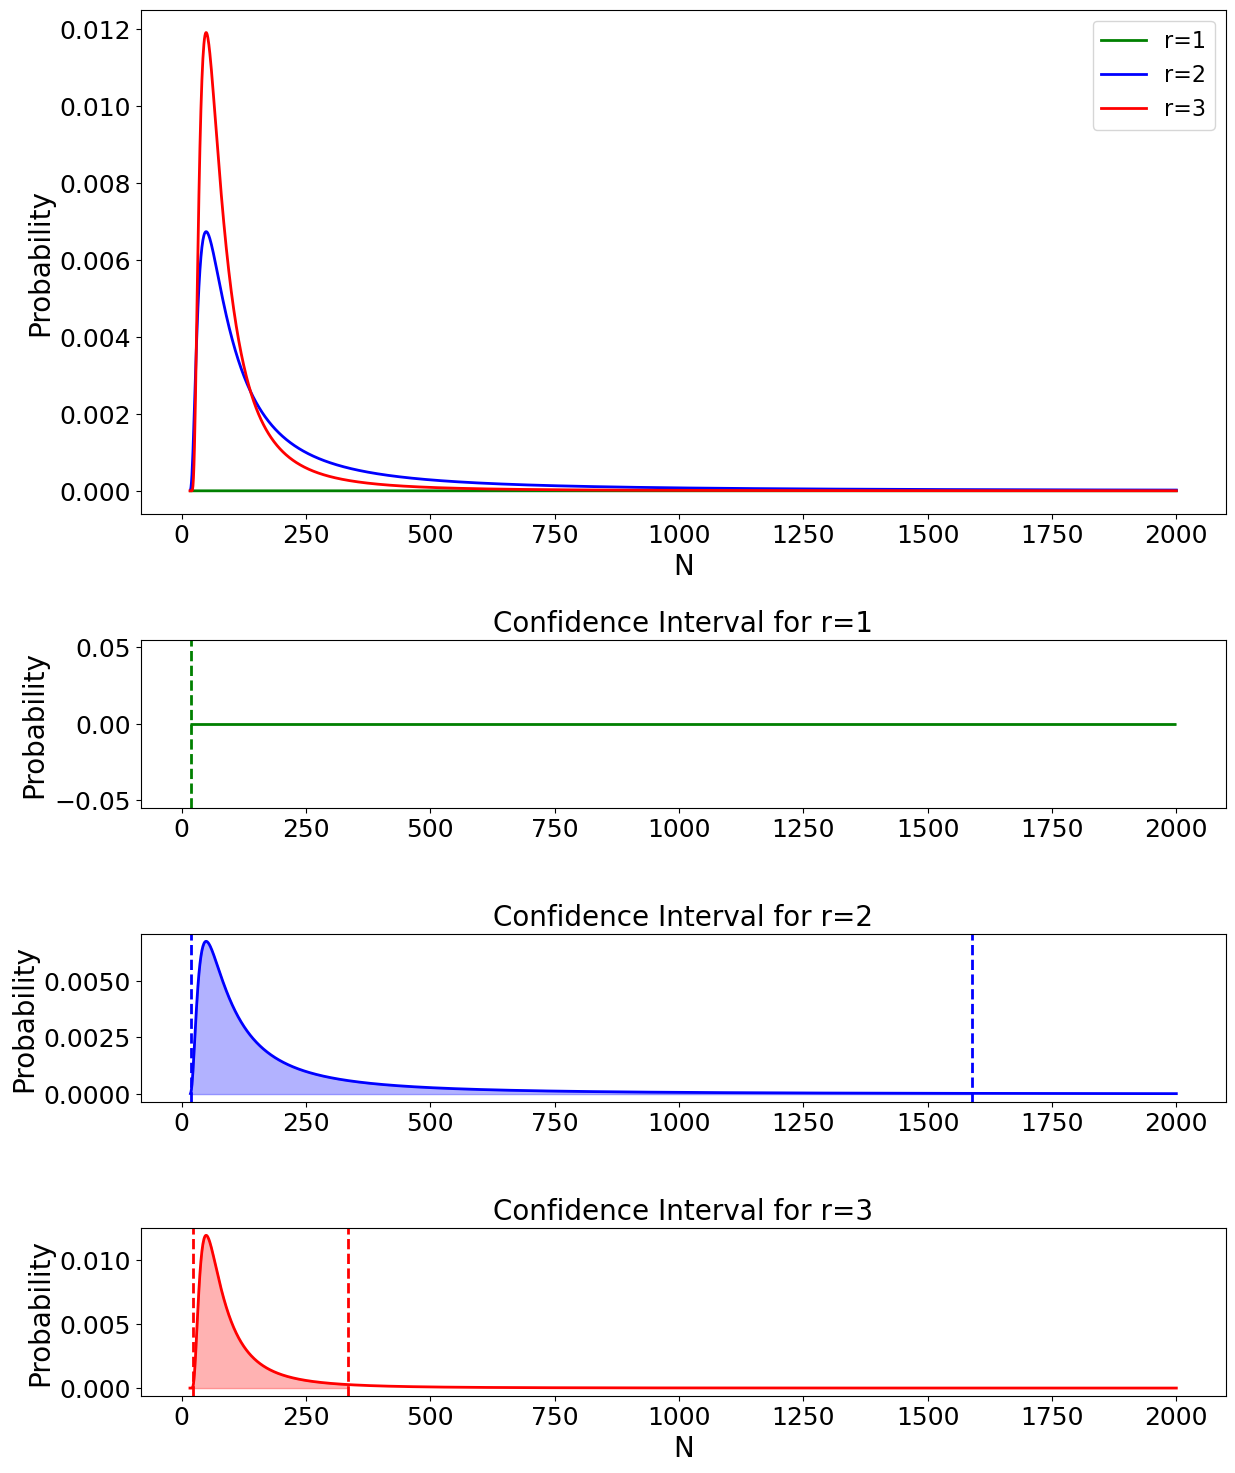

In [2]:
LABEL_FONT_SIZE = 20
TICK_FONT_SIZE = 18
TITLE_FONT_SIZE = 20
LEGEND_FONT_SIZE = 16
LINE_WIDTH = 2

m_1, C_1, r_1 = 10, 10, 1
N_range_1 = range(18, 2001)
expected_probabilities_1 = [0 for _ in N_range_1]

m_2, C_2, r_2 = 10, 10, 2
N_range_2 = range(18, 2001)
expected_probabilities_2 = [
    comb(m_2, r_2) * comb(N - m_2, C_2 - r_2) / comb(N, C_2) / (m_2 * C_2 / (r_2 * (r_2 - 1)))
    for N in N_range_2
]

m_3, C_3, r_3 = 15, 10, 3
N_range_3 = range(17, 2001)
expected_probabilities_3 = [
    comb(m_3, r_3) * comb(N - m_3, C_3 - r_3) / comb(N, C_3) / (m_3 * C_3 / (r_3 * (r_3 - 1)))
    for N in N_range_3
]

CI_1 = (18, np.inf)
CI_2 = (19, 1589)
CI_3 = (24, 334)

color_r1, color_r2, color_r3 = 'green', 'blue', 'red'

fig = plt.figure(figsize=(14, 18))
gs = gridspec.GridSpec(4, 1, height_ratios=[3, 1, 1, 1], hspace=0.5)

ax_main = plt.subplot(gs[0])
ax_main.plot(N_range_1, expected_probabilities_1, color=color_r1, label="r=1", linewidth=LINE_WIDTH)
ax_main.plot(N_range_2, expected_probabilities_2, color=color_r2, label="r=2", linewidth=LINE_WIDTH)
ax_main.plot(N_range_3, expected_probabilities_3, color=color_r3, label="r=3", linewidth=LINE_WIDTH)
ax_main.set_xlabel("N", fontsize=LABEL_FONT_SIZE)
ax_main.set_ylabel("Probability", fontsize=LABEL_FONT_SIZE)
ax_main.tick_params(axis='both', which='major', labelsize=TICK_FONT_SIZE)
ax_main.legend(fontsize=LEGEND_FONT_SIZE)
ax_main.grid(False)

ax1 = plt.subplot(gs[1], sharex=ax_main)
ax1.hlines(0, CI_1[0], 2000, colors=color_r1, linestyles='-', label="r=1 CI", linewidth=LINE_WIDTH)
ax1.fill_betweenx([0, 0.0], CI_1[0], 2000, color=color_r1, alpha=0.3)
ax1.axvline(x=19, color=color_r1, linestyle='--', linewidth=LINE_WIDTH)
ax1.set_ylabel("Probability", fontsize=LABEL_FONT_SIZE)
ax1.set_title("Confidence Interval for r=1", fontsize=TITLE_FONT_SIZE)
ax1.tick_params(axis='both', which='major', labelsize=TICK_FONT_SIZE)
ax1.grid(False)

ax2 = plt.subplot(gs[2], sharex=ax_main)
ax2.plot(N_range_2, expected_probabilities_2, color=color_r2, linewidth=LINE_WIDTH)
ax2.fill_between(N_range_2, expected_probabilities_2,
                 where=((np.array(N_range_2) >= CI_2[0]) & (np.array(N_range_2) <= CI_2[1])),
                 color=color_r2, alpha=0.3)
ax2.axvline(x=CI_2[0], color=color_r2, linestyle='--', linewidth=LINE_WIDTH)
ax2.axvline(x=CI_2[1], color=color_r2, linestyle='--', linewidth=LINE_WIDTH)
ax2.set_ylabel("Probability", fontsize=LABEL_FONT_SIZE)
ax2.set_title("Confidence Interval for r=2", fontsize=TITLE_FONT_SIZE)
ax2.tick_params(axis='both', which='major', labelsize=TICK_FONT_SIZE)
ax2.grid(False)

ax3 = plt.subplot(gs[3], sharex=ax_main)
ax3.plot(N_range_3, expected_probabilities_3, color=color_r3, linewidth=LINE_WIDTH)
ax3.fill_between(N_range_3, expected_probabilities_3,
                 where=((np.array(N_range_3) >= CI_3[0]) & (np.array(N_range_3) <= CI_3[1])),
                 color=color_r3, alpha=0.3)
ax3.axvline(x=CI_3[0], color=color_r3, linestyle='--', linewidth=LINE_WIDTH)
ax3.axvline(x=CI_3[1], color=color_r3, linestyle='--', linewidth=LINE_WIDTH)
ax3.set_ylabel("Probability", fontsize=LABEL_FONT_SIZE)
ax3.set_xlabel("N", fontsize=LABEL_FONT_SIZE)
ax3.set_title("Confidence Interval for r=3", fontsize=TITLE_FONT_SIZE)
ax3.tick_params(axis='both', which='major', labelsize=TICK_FONT_SIZE)
ax3.grid(False)

plt.show()


### Figure 1b

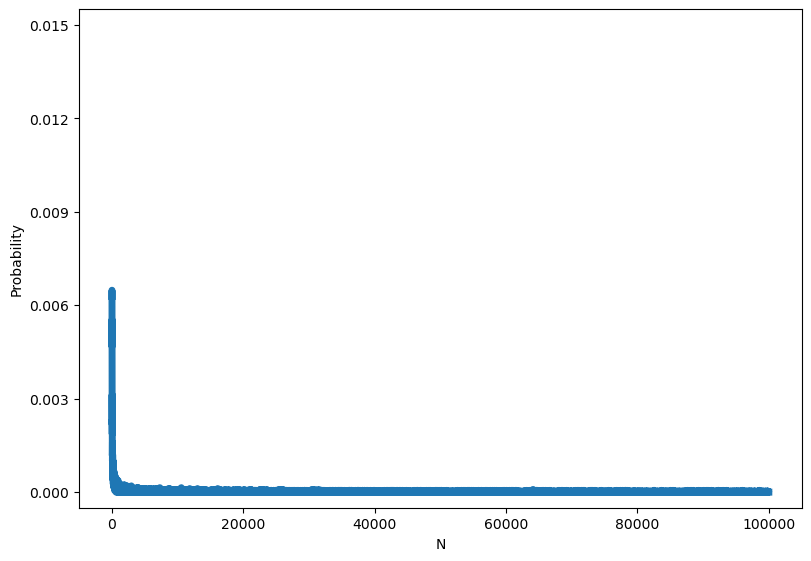

In [5]:
m, C, r = 2, 2, 1
N_range = np.arange(16, 100001)
simulations = 1000

simulated_probabilities = []
for N in N_range:
    draws = hypergeom.rvs(N, m, C, size=simulations)
    simulated_probabilities.append(np.mean(draws == r))

unnormalized_expected = hypergeom.pmf(r, N_range, m, C)
sum_expected = unnormalized_expected.sum()
expected_probabilities = unnormalized_expected / sum_expected

normalized_simulated = np.array(simulated_probabilities) / np.sum(simulated_probabilities)

fig, ax = plt.subplots(figsize=(8, 5.5), constrained_layout=True)
ax.plot(N_range, normalized_simulated, lw=5)
ax.set(xlabel='N', ylabel='Probability', yticks=np.linspace(0, 0.015, 6), ylim=(-0.0005, 0.0155))
plt.show()

### Figure 1c

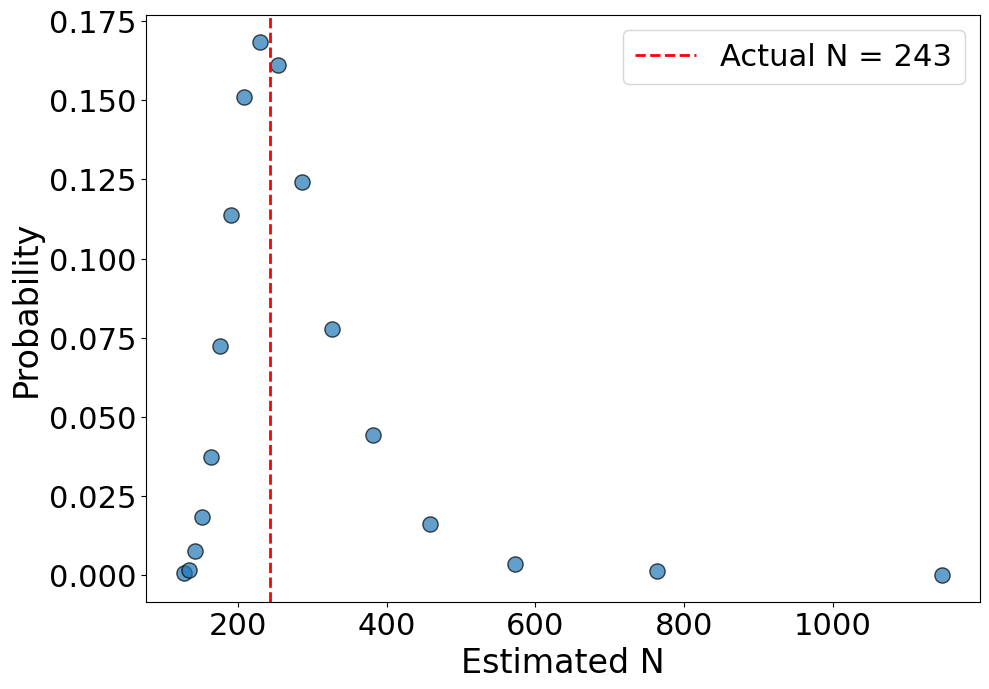

Successful estimates: 10000 of 10000
Mean estimate: 243.93
Median estimate: 228.60
95% Confidence Interval: [152.07, 381.67]


In [10]:
def simulate_mark_recapture(
    population_size: int = 243,
    trials: int = 10_000,
    first_capture: int = 81,
    second_capture: int = 27,
    confidence: float = 0.95,
    seed: int | None = None
) -> tuple[np.ndarray, tuple[float, float]]:

    if seed is not None:
        np.random.seed(seed)

    estimates = []
    for _ in range(trials):
        marked = set(np.random.choice(population_size, size=first_capture, replace=False))
        recaptured = set(np.random.choice(population_size, size=second_capture, replace=False))
        matches = len(marked & recaptured)
        if matches:
            estimate = ((first_capture + 1) * (second_capture + 1) / (matches + 1)) - 1
            estimates.append(estimate)

    estimates_array = np.array(estimates)
    lower_pct = (1 - confidence) / 2 * 100
    upper_pct = (confidence + (1 - confidence) / 2) * 100
    interval = tuple(np.percentile(estimates_array, [lower_pct, upper_pct]))

    distribution = Counter(np.round(estimates_array))
    x_vals = sorted(distribution)
    y_vals = [distribution[x] / sum(distribution.values()) for x in x_vals]

    LABEL_FONT_SIZE = 24
    TICK_FONT_SIZE = 22
    LEGEND_FONT_SIZE = 22

    plt.figure(figsize=(10, 7))
    plt.scatter(x_vals, y_vals, alpha=0.7, edgecolors='black', s=120)
    plt.axvline(x=population_size, linestyle='--', color='red', linewidth=2, label=f'Actual N = {population_size}')
    
    plt.xlabel('Estimated N', fontsize=LABEL_FONT_SIZE)
    plt.ylabel('Probability', fontsize=LABEL_FONT_SIZE)
    plt.xticks(fontsize=TICK_FONT_SIZE)
    plt.yticks(fontsize=TICK_FONT_SIZE)
    plt.legend(fontsize=LEGEND_FONT_SIZE)
    plt.grid(False)
    plt.tight_layout()
    plt.show()

    return estimates_array, interval

if __name__ == '__main__':
    ACTUAL_N = 243
    TRIALS = 10_000
    FIRST_CAPTURE = 81
    SECOND_CAPTURE = 27
    CONF_LEVEL = 0.95
    SEED = 42

    estimates, conf_int = simulate_mark_recapture(
        population_size=ACTUAL_N,
        trials=TRIALS,
        first_capture=FIRST_CAPTURE,
        second_capture=SECOND_CAPTURE,
        confidence=CONF_LEVEL,
        seed=SEED
    )

    print(f"Successful estimates: {len(estimates)} of {TRIALS}")
    print(f"Mean estimate: {np.mean(estimates):.2f}")
    print(f"Median estimate: {np.median(estimates):.2f}")
    print(f"{int(CONF_LEVEL*100)}% Confidence Interval: [{conf_int[0]:.2f}, {conf_int[1]:.2f}]");

### Figure 1d

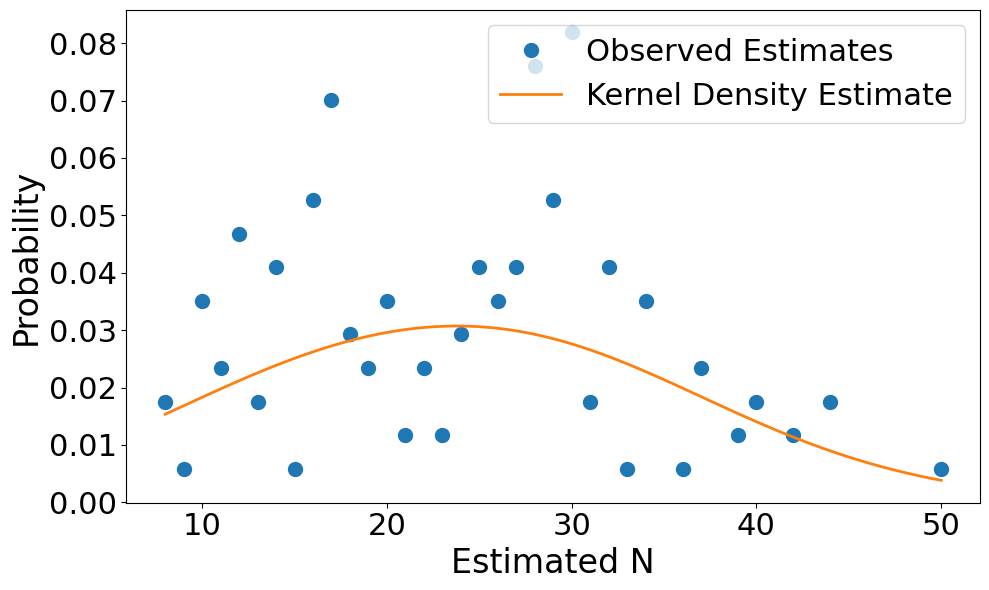

In [ ]:
def plot_estimate_distribution(file_path, threshold=100, bw_method=1, figsize=(10, 6)):
    df = pd.read_excel(file_path)
    df['estimate'] = df['estimate'].round().astype(int)
    df = df[df['estimate'] <= threshold]

    freq = df['estimate'].value_counts().sort_index()
    prob = freq / freq.sum()

    x = np.linspace(df['estimate'].min(), df['estimate'].max(), 100)
    kde = gaussian_kde(df['estimate'], bw_method=bw_method)(x)
    
    LABEL_FONT_SIZE = 24
    TICK_FONT_SIZE = 22
    LEGEND_FONT_SIZE = 22

    plt.figure(figsize=figsize)
    plt.plot(prob.index, prob.values, 'o', markersize=10, label='Observed Estimates')
    plt.plot(x, kde, '-', linewidth=LINE_WIDTH, label='Kernel Density Estimate')
    plt.xlabel('Estimated N', fontsize=LABEL_FONT_SIZE)
    plt.ylabel('Probability', fontsize=LABEL_FONT_SIZE)
    plt.xticks(fontsize=TICK_FONT_SIZE)
    plt.yticks(fontsize=TICK_FONT_SIZE)
    plt.legend(fontsize=LEGEND_FONT_SIZE)
    plt.grid(False)
    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    data_path = r"./data/Hinneberg_et_al_2022_Multi_Surveyor_CMR_resultsfile.xlsx"
    plot_estimate_distribution(data_path)

### Figure 2

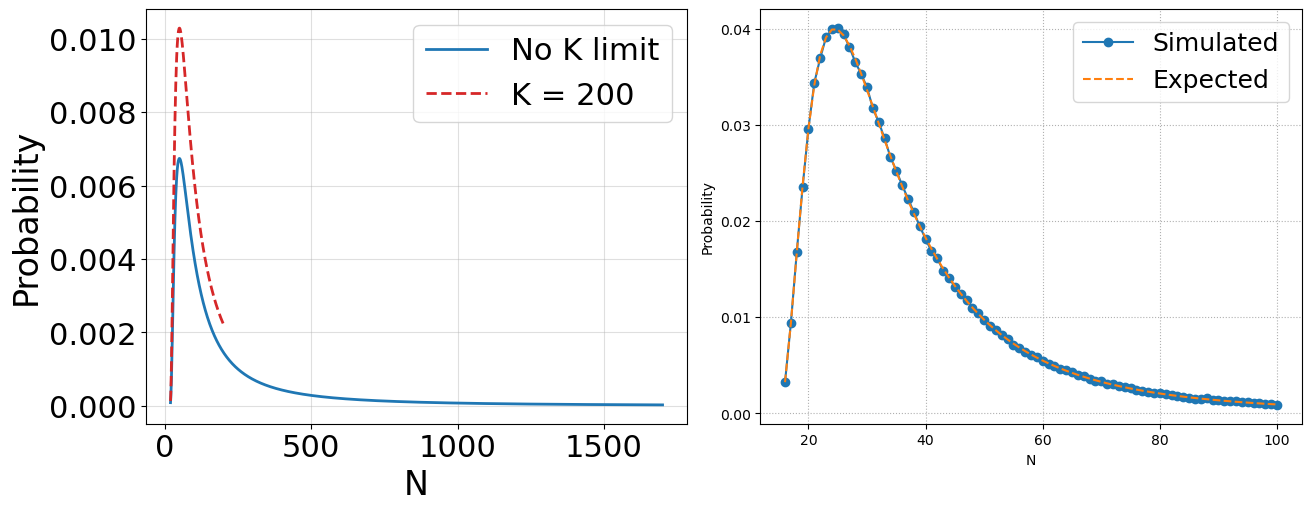

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13.,5),constrained_layout=True)

axes = axes.flatten()


label_fs = 24
tick_fs = 22
legend_fs = 22

params = [
    {'K': None,   'm': 10, 'C': 10, 'r': 2, 'N_min': 19, 'N_max': 1700, 'Sum': 10 * 10 / (2 * (2 - 1)), 'CI': (19, 1589), 'color': 'tab:blue',   'label': 'No K limit', 'linestyle': '-'} ,
    {'K': 200,    'm': 10, 'C': 10, 'r': 2, 'N_min': 19, 'N_max': 200,  'Sum':32.749628585823295, 'CI': (25, 182),  'color': 'tab:red',    'label': 'K = 200',    'linestyle': '--'},
]


for p in params:
    N_range = np.arange(p['N_min'], p['N_max'] + 1)
    probs = comb(p['m'], p['r']) * comb(N_range - p['m'], p['C'] - p['r']) / comb(N_range, p['C']) / p['Sum']
    axes[0].plot(N_range, probs, linestyle=p['linestyle'], color=p['color'], label=p['label'], linewidth=2)
    mask = (N_range >= p['CI'][0]) & (N_range <= p['CI'][1])




axes[0].set_xlabel("N", fontsize=label_fs)
axes[0].set_ylabel("Probability", fontsize=label_fs)
axes[0].tick_params(axis='both', which='major', labelsize=tick_fs)
axes[0].tick_params(axis='both', which='minor', labelsize=tick_fs)
axes[0].legend(fontsize=legend_fs, loc='upper right')
axes[0].grid(alpha=0.4)


# Configuration
params = {
    'marked_count': 10,
    'sample_size': 10,
    'target_recaptured': 4,
    'normalization_constant': 8.06,
    'population_min': 16,
    'population_max': 100,
    'population_step': 1,
    'simulations': 100000,
    'font_size': 20,
    'figure_size': (8, 5),
    'dpi': 300
}

populations = np.arange(
    params['population_min'],
    params['population_max'] + 1,
    params['population_step']
)
simulated_probs = []
expected_probs = []

for N in populations:
    marked = np.zeros(N)
    marked[:params['marked_count']] = 1
    success_count = 0

    for _ in range(params['simulations']):
        np.random.shuffle(marked)
        if np.sum(marked[:params['sample_size']]) == params['target_recaptured']:
            success_count += 1

    simulated_probs.append(success_count / params['simulations'])
    expected = (
        comb(params['marked_count'], params['target_recaptured'])
        * comb(N - params['marked_count'], params['sample_size'] - params['target_recaptured'])
        / comb(N, params['sample_size'])
    ) / params['normalization_constant']
    expected_probs.append(expected)

simulated_probs = np.array(simulated_probs)
simulated_probs /= simulated_probs.sum()

plt.rcParams.update({
    'font.size': params['font_size'],
    'axes.labelsize': params['font_size'],
    'legend.fontsize': params['font_size'] * 0.9,
    'xtick.labelsize': params['font_size'] * 0.9,
    'ytick.labelsize': params['font_size'] * 0.9
})


axes[1].plot(
    populations,
    simulated_probs,
    marker='o',
    linestyle='-'
)
axes[1].plot(
    populations,
    expected_probs,
    linestyle='--'
)
axes[1].set_xlabel('N')
axes[1].set_ylabel('Probability')
axes[1].legend(['Simulated', 'Expected'], loc='best')
axes[1].grid(True, linestyle=':')


plt.show();

### Figure 3a

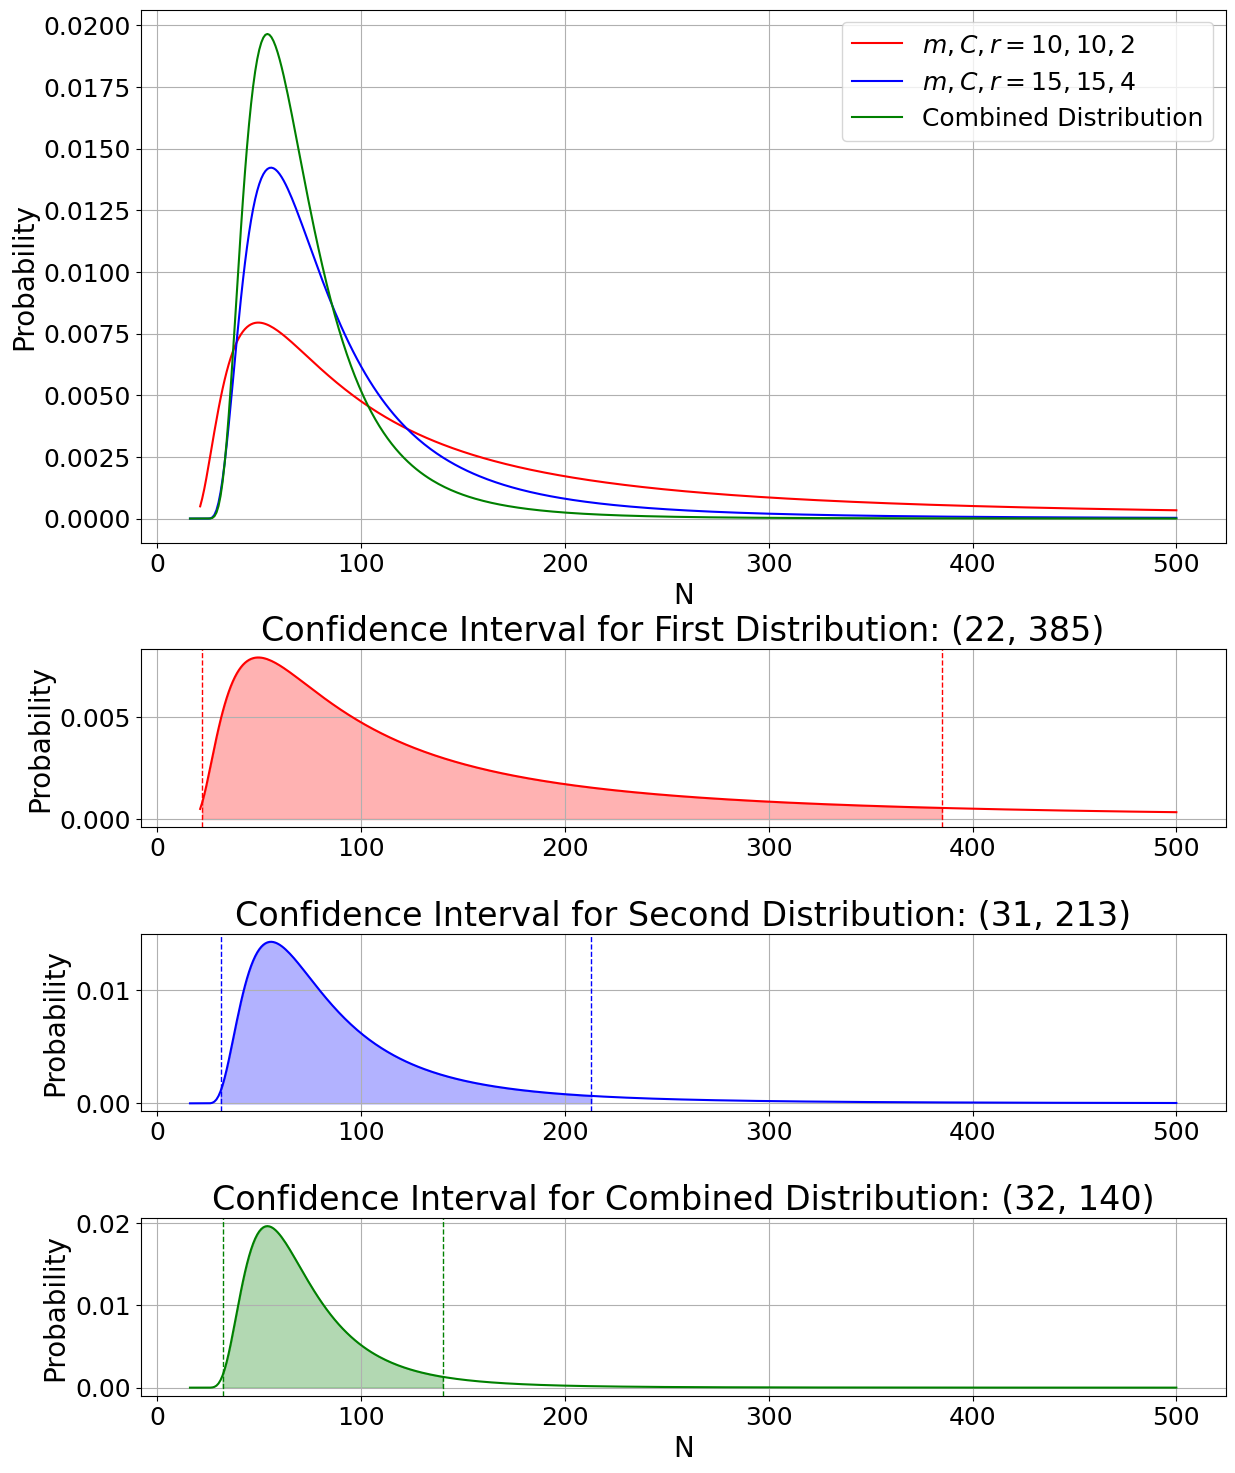

In [22]:
m = 10
C = 10
r = 2
N_min = 21
N_max = 500
Sum = 42.403
expected_probabilities = []
N_range = range(N_min, N_max + 1, 1)

for N in N_range:
    expected_probability = comb(m, r) * comb(N - m, C - r) / comb(N, C) / Sum
    expected_probabilities.append(expected_probability)

m_2 = 15
C_2 = 15
r_2 = 4
N_min_2 = 16
Sum_2 = 18.650
expected_probabilities_2 = []
N_range_2 = range(N_min_2, N_max + 1, 1)

for N in N_range_2:
    expected_probability_2 = comb(m_2, r_2) * comb(N - m_2, C_2 - r_2) / comb(N, C_2) / Sum_2
    expected_probabilities_2.append(expected_probability_2)

combined_probabilities = []
Sum_3 = 0
for i in range(len(N_range_2)):
    N = N_range_2[i]
    expected_probability = comb(m, r) * comb(N - m, C - r) / comb(N, C) / Sum
    expected_probability_2 = comb(m_2, r_2) * comb(N - m_2, C_2 - r_2) / comb(N, C_2) / Sum_2
    Sum_3 += expected_probability * expected_probability_2

for i in range(len(N_range_2)):
    N = N_range_2[i]
    expected_probability = comb(m, r) * comb(N - m, C - r) / comb(N, C) / Sum
    expected_probability_2 = comb(m_2, r_2) * comb(N - m_2, C_2 - r_2) / comb(N, C_2) / Sum_2
    combined_probability = expected_probability * expected_probability_2 / Sum_3
    combined_probabilities.append(combined_probability)

CI_first = (22, 385)
CI_second = (31, 213) 
CI_combined = (32, 140)

color_first = 'red'
color_second = 'blue'
color_combined = 'green'

fig = plt.figure(figsize=(14, 18))
gs = gridspec.GridSpec(4, 1, height_ratios=[3, 1, 1, 1], hspace=0.4)

ax_main = plt.subplot(gs[0])
ax_main.plot(N_range, expected_probabilities, linestyle='-', color=color_first, label="$m, C, r =10, 10, 2$")
ax_main.plot(N_range_2, expected_probabilities_2, linestyle='-', color=color_second, label="$m, C, r = 15, 15, 4$")
ax_main.plot(N_range_2, combined_probabilities, linestyle='-', color=color_combined, label="Combined Distribution")
ax_main.set_xlabel("N")
ax_main.set_ylabel("Probability")
ax_main.legend()
ax_main.grid(True)

ax1 = plt.subplot(gs[1], sharex=ax_main)
ax1.plot(N_range, expected_probabilities, color=color_first)
ax1.fill_between(
    N_range,
    expected_probabilities,
    where=((np.array(list(N_range)) >= CI_first[0]) & (np.array(list(N_range)) <= CI_first[1])),
    color=color_first,
    alpha=0.3
)

prob_first_start = expected_probabilities[CI_first[0] - N_min]
prob_first_end = expected_probabilities[CI_first[1] - N_min]
ax1.axvline(
    x=CI_first[0],
    color=color_first,
    linestyle='--',
    linewidth=1
)
ax1.axvline(
    x=CI_first[1],
    color=color_first,
    linestyle='--',
    linewidth=1
)
ax1.set_ylabel("Probability")
ax1.set_title(f"Confidence Interval for First Distribution: {CI_first}")
ax1.grid(True)

ax2 = plt.subplot(gs[2], sharex=ax_main)
ax2.plot(N_range_2, expected_probabilities_2, color=color_second)
ax2.fill_between(
    N_range_2,
    expected_probabilities_2,
    where=((np.array(list(N_range_2)) >= CI_second[0]) & (np.array(list(N_range_2)) <= CI_second[1])),
    color=color_second,
    alpha=0.3
)

prob_second_start = expected_probabilities_2[CI_second[0] - N_min_2]
prob_second_end = expected_probabilities_2[CI_second[1] - N_min_2]
ax2.axvline(
    x=CI_second[0],
    color=color_second,
    linestyle='--',
    linewidth=1
)
ax2.axvline(
    x=CI_second[1],
    color=color_second,
    linestyle='--',
    linewidth=1
)
ax2.set_ylabel("Probability")
ax2.set_title(f"Confidence Interval for Second Distribution: {CI_second}")
ax2.grid(True)

ax3 = plt.subplot(gs[3], sharex=ax_main)
ax3.plot(N_range_2, combined_probabilities, color=color_combined)
ax3.fill_between(
    N_range_2,
    combined_probabilities,
    where=((np.array(list(N_range_2)) >= CI_combined[0]) & (np.array(list(N_range_2)) <= CI_combined[1])),
    color=color_combined,
    alpha=0.3
)

prob_combined_start = combined_probabilities[CI_combined[0] - N_min_2]
prob_combined_end = combined_probabilities[CI_combined[1] - N_min_2]
ax3.axvline(
    x=CI_combined[0],
    color=color_combined,
    linestyle='--',
    linewidth=1
)
ax3.axvline(
    x=CI_combined[1],
    color=color_combined,
    linestyle='--',
    linewidth=1
)
ax3.set_ylabel("Probability")
ax3.set_title(f"Confidence Interval for Combined Distribution: {CI_combined}")
ax3.set_xlabel("N")
ax3.grid(True)

plt.show();

### Figure 3b

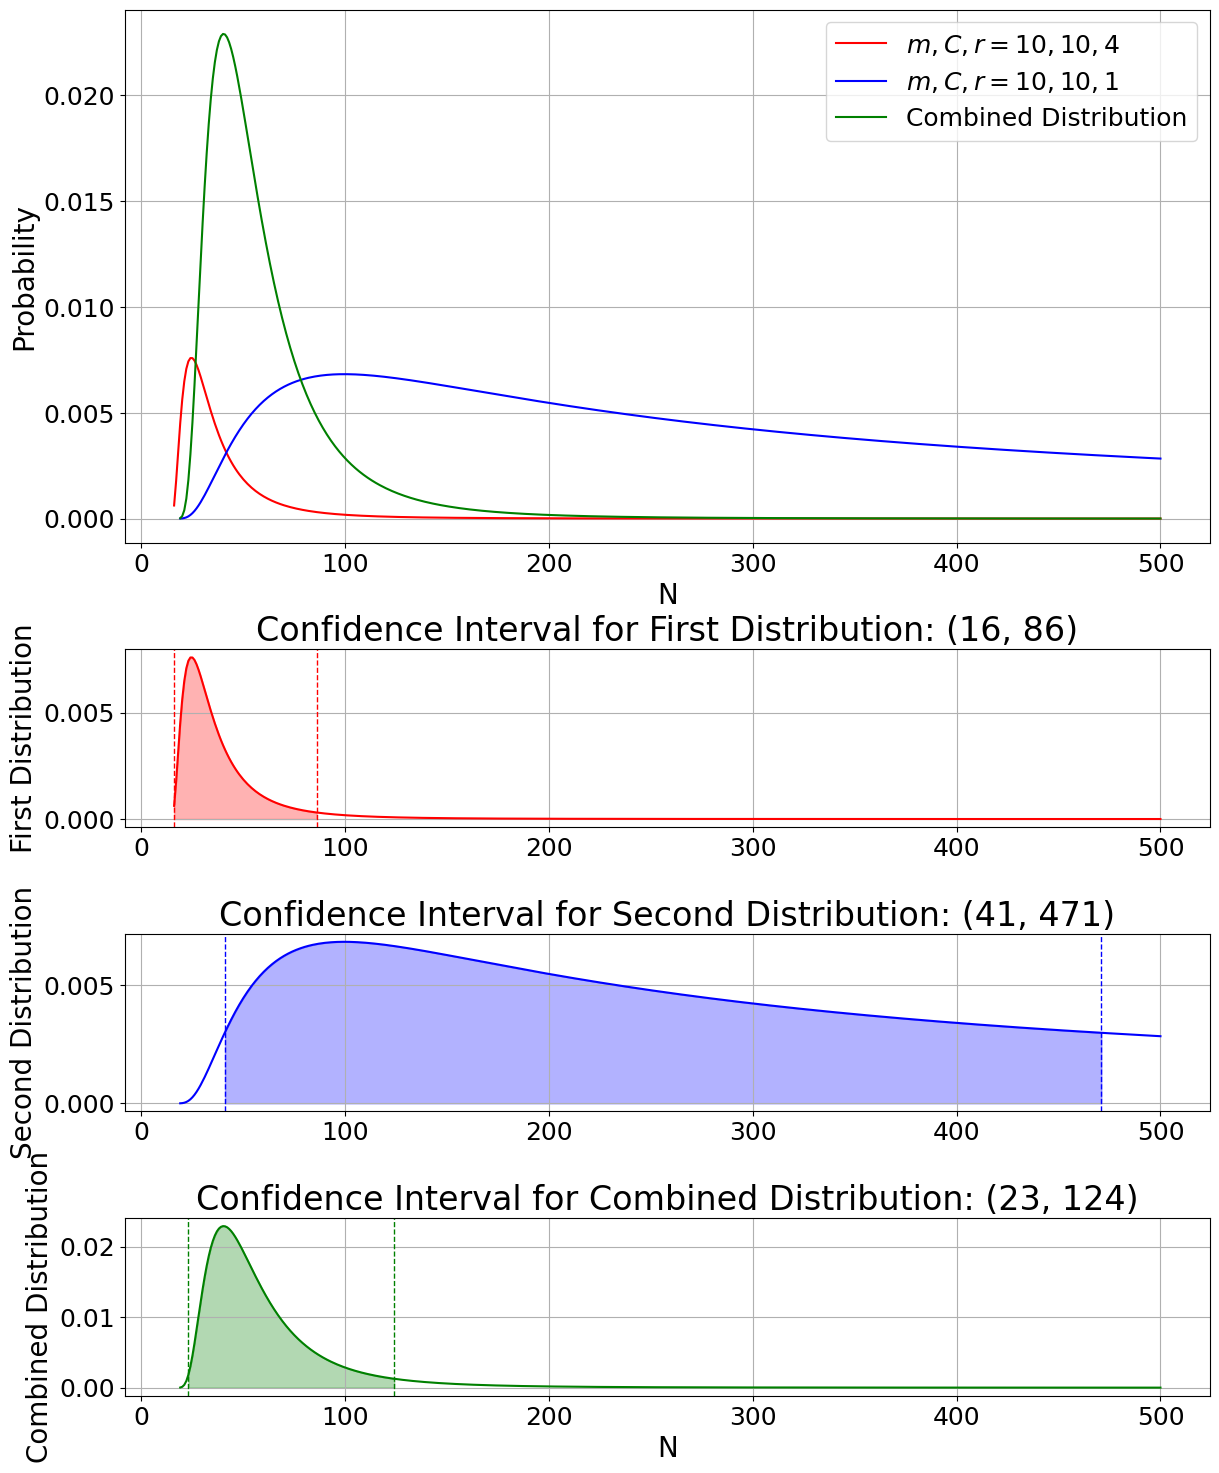

In [23]:
m_1 = 10
C_1 = 10
r_1 = 4
N_min_1 = m_1 + C_1 - r_1
N_max = 500
Sum_1 = 42.402
expected_probabilities_1 = []
N_range_1 = range(N_min_1, N_max + 1, 1)

for N in N_range_1:
    expected_probability_1 = comb(m_1, r_1) * comb(N - m_1, C_1 - r_1) / comb(N, C_1) / Sum_1
    expected_probabilities_1.append(expected_probability_1)

m_2 = 10
C_2 = 10
r_2 = 1
N_min_2 = m_2 + C_2 - r_2
Sum_2 = 59.793
expected_probabilities_2 = []
N_range_2 = range(N_min_2, N_max + 1, 1)

for N in N_range_2:
    expected_probability_2 = comb(m_2, r_2) * comb(N - m_2, C_2 - r_2) / comb(N, C_2) / Sum_2
    expected_probabilities_2.append(expected_probability_2)

combined_probabilities = []
Sum_3 = 0
for i in range(len(N_range_2)):
    N = N_range_2[i]
    expected_probability_1 = comb(m_1, r_1) * comb(N - m_1, C_1 - r_1) / comb(N, C_1) / Sum_1
    expected_probability_2 = comb(m_2, r_2) * comb(N - m_2, C_2 - r_2) / comb(N, C_2) / Sum_2
    Sum_3 += expected_probability_1 * expected_probability_2

for i in range(len(N_range_2)):
    N = N_range_2[i]
    expected_probability_1 = comb(m_1, r_1) * comb(N - m_1, C_1 - r_1) / comb(N, C_1) / Sum_1
    expected_probability_2 = comb(m_2, r_2) * comb(N - m_2, C_2 - r_2) / comb(N, C_2) / Sum_2
    combined_probability = expected_probability_1 * expected_probability_2 / Sum_3
    combined_probabilities.append(combined_probability)

CI_first = (16, 86)
CI_second = (41, 471)
CI_combined = (23, 124)

color_first = 'red'
color_second = 'blue'
color_combined = 'green'

fig = plt.figure(figsize=(14, 18))
gs = gridspec.GridSpec(4, 1, height_ratios=[3, 1, 1, 1], hspace=0.4)

# Main Plot
ax_main = plt.subplot(gs[0])
ax_main.plot(N_range_1, expected_probabilities_1, linestyle='-', color=color_first, label="$m, C, r = 10, 10, 4$")
ax_main.plot(N_range_2, expected_probabilities_2, linestyle='-', color=color_second, label="$m, C, r = 10, 10, 1$")
ax_main.plot(N_range_2, combined_probabilities, linestyle='-', color=color_combined, label="Combined Distribution")
ax_main.set_xlabel("N")
ax_main.set_ylabel("Probability")
ax_main.legend()
ax_main.grid(True)

ax1 = plt.subplot(gs[1], sharex=ax_main)
ax1.plot(N_range_1, expected_probabilities_1, color=color_first)
ax1.fill_between(
    N_range_1,
    expected_probabilities_1,
    where=((np.array(N_range_1) >= CI_first[0]) & (np.array(N_range_1) <= CI_first[1])),
    color=color_first,
    alpha=0.3
)

ax1.axvline(
    x=CI_first[0],
    color=color_first,
    linestyle='--',
    linewidth=1
)
ax1.axvline(
    x=CI_first[1],
    color=color_first,
    linestyle='--',
    linewidth=1
)
ax1.set_ylabel("First Distribution")
ax1.set_title(f"Confidence Interval for First Distribution: {CI_first}")
ax1.grid(True)

ax2 = plt.subplot(gs[2], sharex=ax_main)
ax2.plot(N_range_2, expected_probabilities_2, color=color_second)
ax2.fill_between(
    N_range_2,
    expected_probabilities_2,
    where=((np.array(N_range_2) >= CI_second[0]) & (np.array(N_range_2) <= CI_second[1])),
    color=color_second,
    alpha=0.3
)

ax2.axvline(
    x=CI_second[0],
    color=color_second,
    linestyle='--',
    linewidth=1
)
ax2.axvline(
    x=CI_second[1],
    color=color_second,
    linestyle='--',
    linewidth=1
)
ax2.set_ylabel("Second Distribution")
ax2.set_title(f"Confidence Interval for Second Distribution: {CI_second}")
ax2.grid(True)

ax3 = plt.subplot(gs[3], sharex=ax_main)
ax3.plot(N_range_2, combined_probabilities, color=color_combined)
ax3.fill_between(
    N_range_2,
    combined_probabilities,
    where=((np.array(N_range_2) >= CI_combined[0]) & (np.array(N_range_2) <= CI_combined[1])),
    color=color_combined,
    alpha=0.3
)

ax3.axvline(
    x=CI_combined[0],
    color=color_combined,
    linestyle='--',
    linewidth=1
)
ax3.axvline(
    x=CI_combined[1],
    color=color_combined,
    linestyle='--',
    linewidth=1
)
ax3.set_ylabel("Combined Distribution")
ax3.set_title(f"Confidence Interval for Combined Distribution: {CI_combined}")
ax3.set_xlabel("N")
ax3.grid(True)

plt.show();

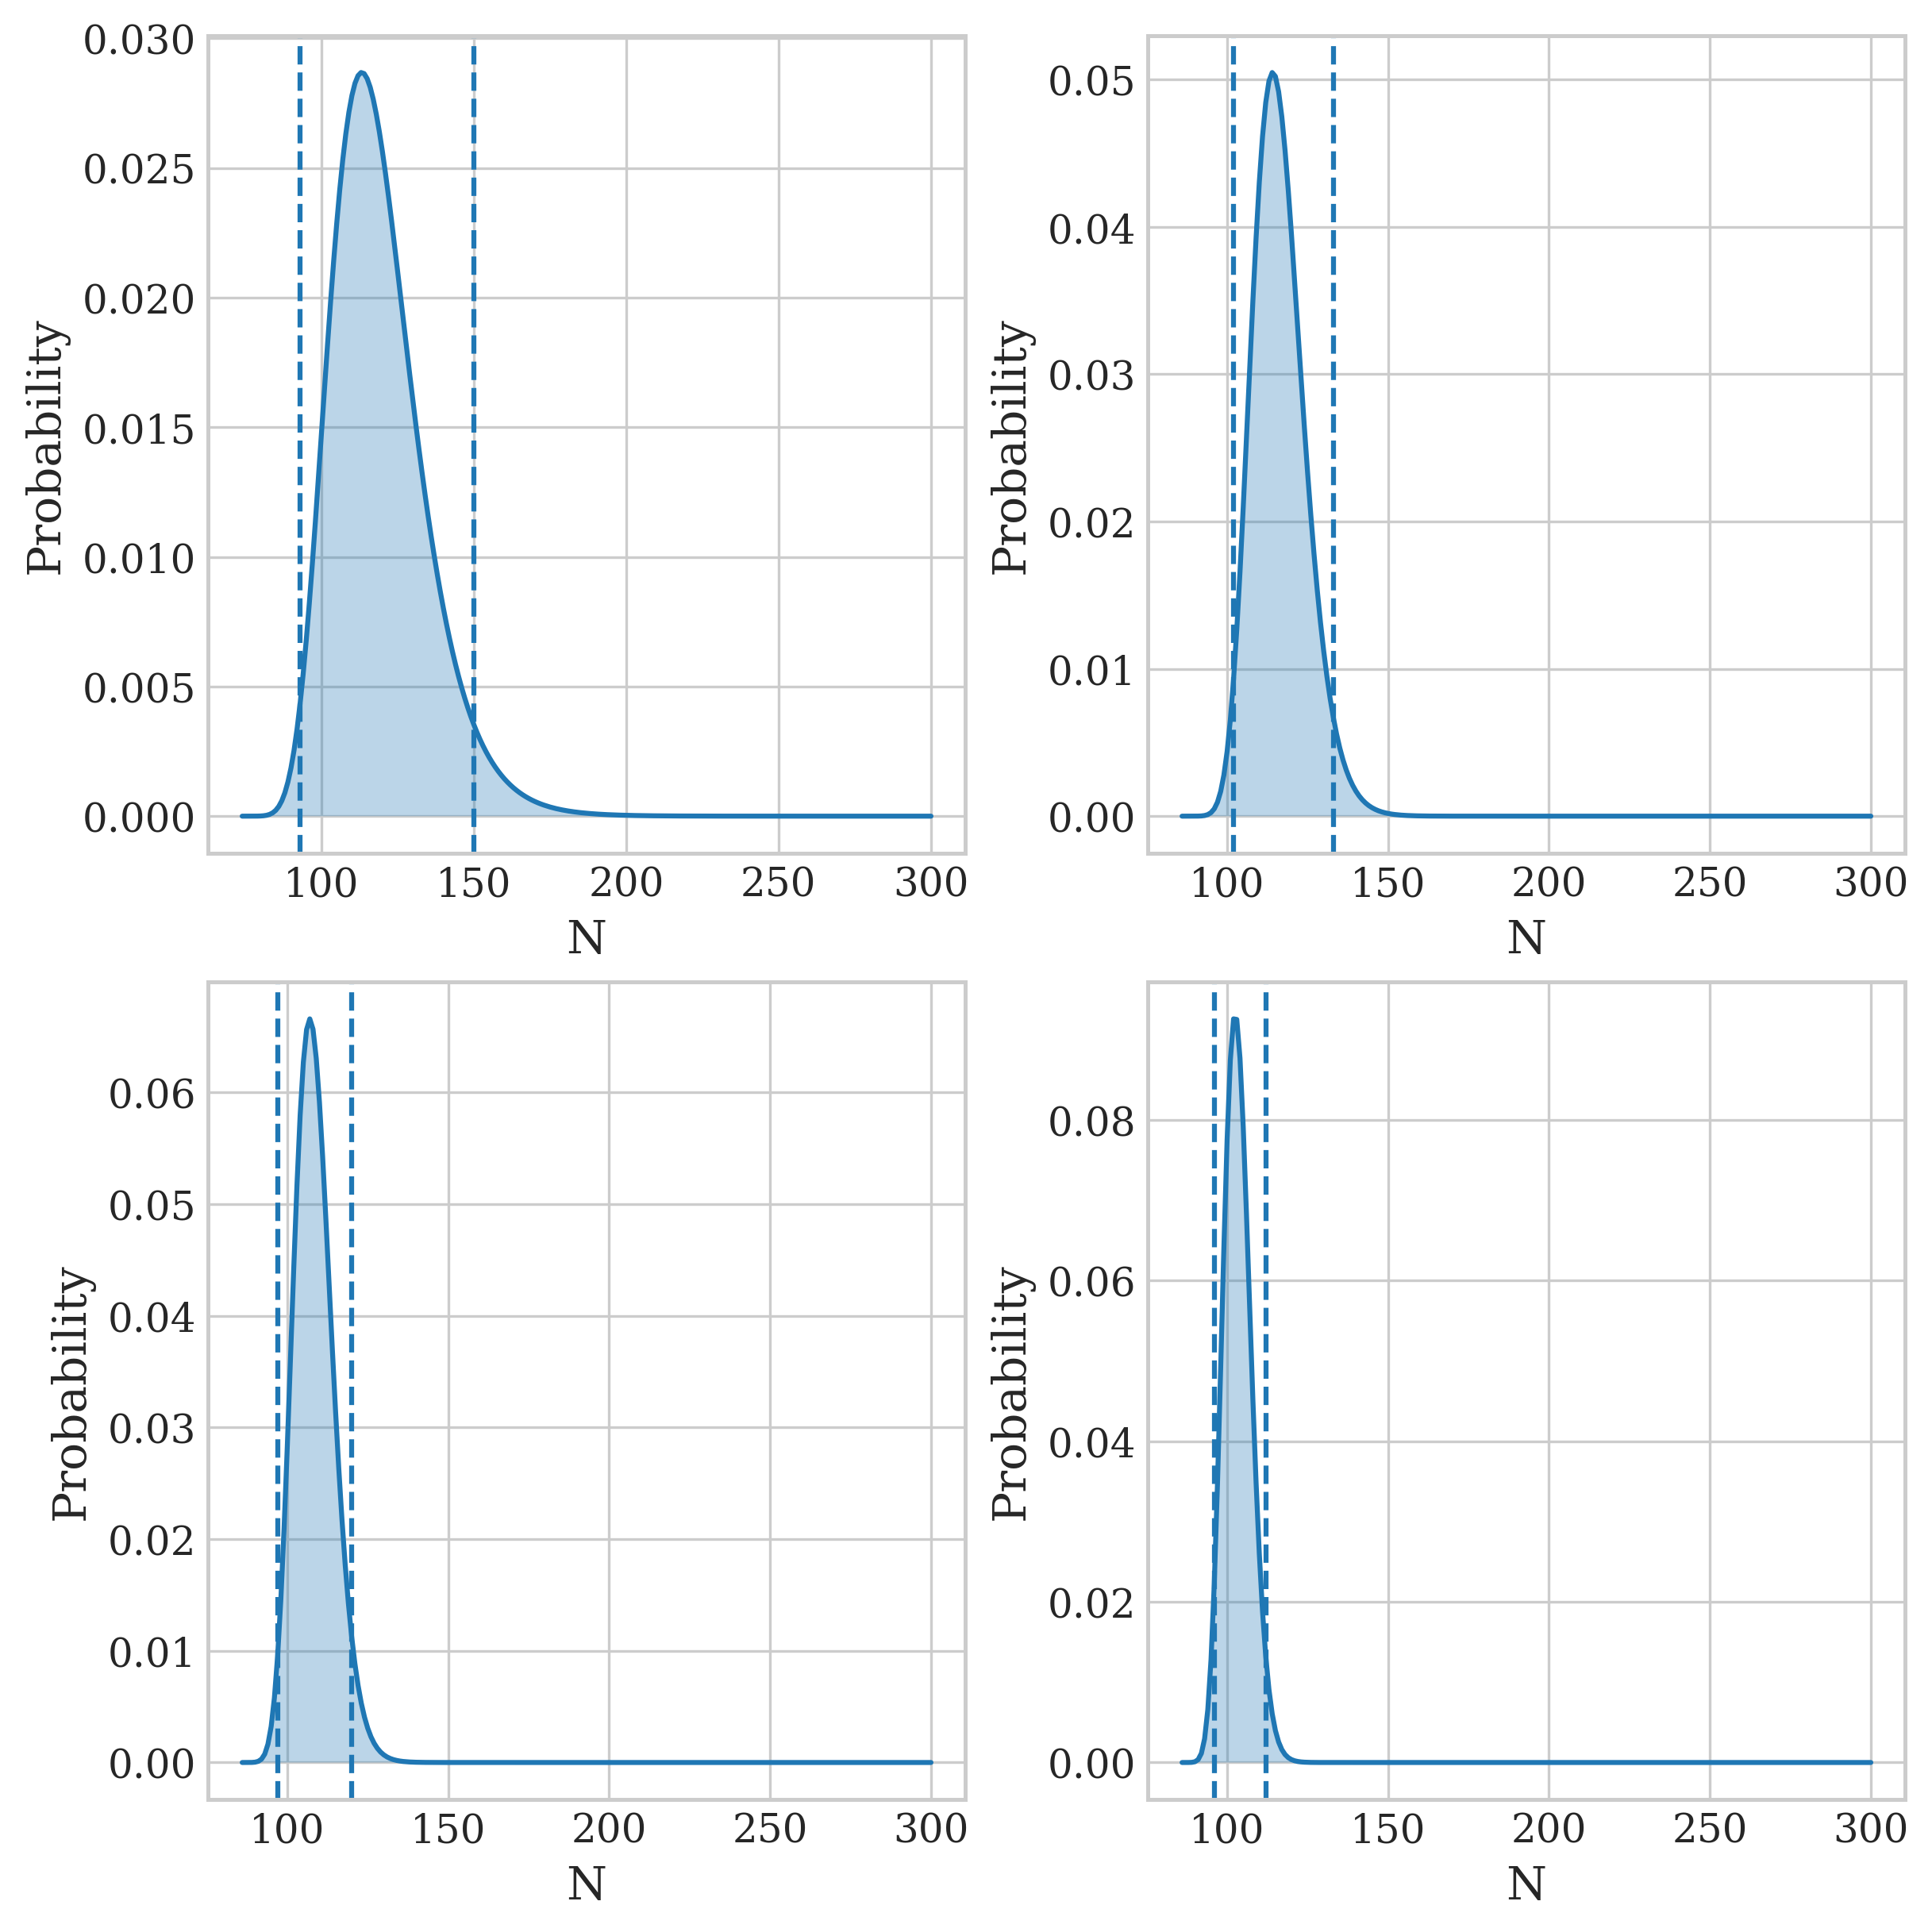

In [54]:
#Figure 4, Step 2
import csv
import math
from scipy.special import comb
import numpy as np
import matplotlib.pyplot as plt


def log_comb(n, k, cache={}):
    if (n, k) in cache:
        return cache[(n, k)]
    if n < k or k < 0:
        val = float('-inf')
    else:
        val = math.log(comb(n, k))
    cache[(n, k)] = val
    return val


def logsumexp(a):
    m = np.max(a)
    return m + math.log(np.sum(np.exp(a - m)))

def single_log_pmf(m, C, r, domain):
    log_mass = np.array([log_comb(m, r) + log_comb(x - m, C - r) - log_comb(x, C)
                          for x in domain], dtype=float)
    log_Z = logsumexp(log_mass)
    return log_mass - log_Z


def multi_dataset_posterior(data_sets, K):
    min_support = max(m + C - r for m, C, r in data_sets)
    domain = np.arange(min_support, K + 1)

    total_log_p = np.zeros_like(domain, dtype=float)
    for m, C, r in data_sets:
        log_p = single_log_pmf(m, C, r, domain)
        total_log_p += log_p

    log_Z_joint = logsumexp(total_log_p)
    log_posterior = total_log_p - log_Z_joint
    posterior = np.exp(log_posterior)
    return domain, posterior

def shortest_hpd_interval(domain, pmf, alpha=0.05):
    idx = np.argsort(pmf)[::-1]
    cum = 0.0
    selected = []
    for i in idx:
        selected.append(domain[i])
        cum += pmf[i]
        if cum >= 1 - alpha:
            break
    return min(selected), max(selected)


def expectation_median(domain, pmf):
    exp_val = float(np.dot(domain, pmf))
    cdf = np.cumsum(pmf)
    med = int(domain[np.searchsorted(cdf, 0.5)])
    return exp_val, med

def read_csv(file_path):
    data_sets = []
    with open(file_path, newline='') as csvfile:
        reader = csv.DictReader(csvfile)
        for row in reader:
            data_sets.append((int(row['m']), int(row['C']), int(row['r'])))
    return data_sets

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(8, 8),constrained_layout=True)

axes = axes.flatten()


csv_file = pd.read_excel("./data/Data_Khelifa_et_al._2021_Sci.Rep.xlsx", sheet_name=0)
K = 300
alpha = 0.05

data_sets = ((39,49,14),(47,25,14))
domain, posterior = multi_dataset_posterior(data_sets, K)
ci_low, ci_high = shortest_hpd_interval(domain, posterior, alpha)
exp_val, med = expectation_median(domain, posterior)
center = sum(m * C for m, C, r in data_sets) / sum(r for m, C, r in data_sets)
axes[0].plot(domain, posterior)
axes[0].fill_between(domain, posterior, alpha=0.3)
axes[0].axvline(ci_low, linestyle='--', label='Lower CI')
axes[0].axvline(ci_high, linestyle='--', label='Upper CI')
axes[0].set_xlabel('N')
axes[0].set_ylabel('Probability')

data_sets = ((39,49,14),(47,25,14),(34,50,18),(50,60,24))
domain, posterior = multi_dataset_posterior(data_sets, K)
ci_low, ci_high = shortest_hpd_interval(domain, posterior, alpha)
exp_val, med = expectation_median(domain, posterior)
center = sum(m * C for m, C, r in data_sets) / sum(r for m, C, r in data_sets)
axes[1].plot(domain, posterior)
axes[1].fill_between(domain, posterior, alpha=0.3)
axes[1].axvline(ci_low, linestyle='--', label='Lower CI')
axes[1].axvline(ci_high, linestyle='--', label='Upper CI')
axes[1].set_xlabel('N')
axes[1].set_ylabel('Probability')

data_sets = ((39,49,14),(47,25,14),(34,50,18),(50,60,24),(39,28,15),(27,33,12))
domain, posterior = multi_dataset_posterior(data_sets, K)
ci_low, ci_high = shortest_hpd_interval(domain, posterior, alpha)
exp_val, med = expectation_median(domain, posterior)
center = sum(m * C for m, C, r in data_sets) / sum(r for m, C, r in data_sets)
axes[2].plot(domain, posterior)
axes[2].fill_between(domain, posterior, alpha=0.3)
axes[2].axvline(ci_low, linestyle='--', label='Lower CI')
axes[2].axvline(ci_high, linestyle='--', label='Upper CI')
axes[2].set_xlabel('N')
axes[2].set_ylabel('Probability')


data_sets = ((39,49,14),(47,25,14),(34,50,18),(50,60,24),(39,28,15),(27,33,12),(35,35,13),(42,51,20),(42,41,20),(32,45,17))
domain, posterior = multi_dataset_posterior(data_sets, K)
ci_low, ci_high = shortest_hpd_interval(domain, posterior, alpha)
exp_val, med = expectation_median(domain, posterior)
center = sum(m * C for m, C, r in data_sets) / sum(r for m, C, r in data_sets)
axes[3].plot(domain, posterior)
axes[3].fill_between(domain, posterior, alpha=0.3)
axes[3].axvline(ci_low, linestyle='--', label='Lower CI')
axes[3].axvline(ci_high, linestyle='--', label='Upper CI')
axes[3].set_xlabel('N')
axes[3].set_ylabel('Probability')
plt.show();

### Figure 5a

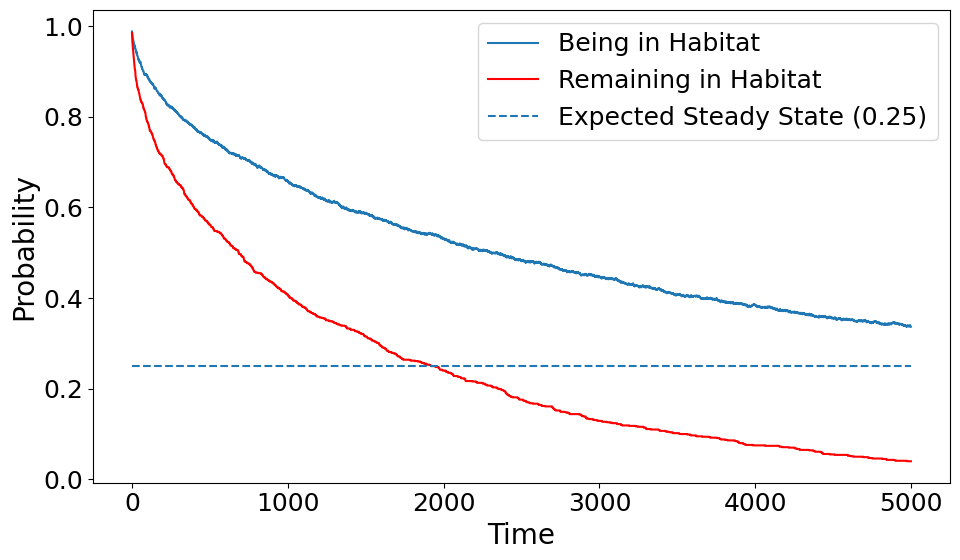

In [26]:
class Simulation:
    """
    Simulates random-walk particles within concentric circles and tracks
    their occupancy statistics.
    """
    def __init__(
        self,
        outer_radius: float,
        inner_radius: float,
        speed: float,
        dt: float,
        n_particles: int,
        n_steps: int,
        seed: int = 0
    ) -> None:
        self.R_outer = outer_radius
        self.R_inner = inner_radius
        self.speed = speed
        self.dt = dt
        self.n = n_particles
        self.steps = n_steps
        self.rng = np.random.default_rng(seed)

        angles = self.rng.uniform(0, 2 * np.pi, self.n)
        radii = np.sqrt(self.rng.uniform(0, self.R_inner**2, self.n))
        self.x = radii * np.cos(angles)
        self.y = radii * np.sin(angles)

        self.has_exited = np.zeros(self.n, dtype=bool)

    def step(self) -> None:
        dirs = self.rng.uniform(0, 2 * np.pi, self.n)
        dx = np.cos(dirs) * self.speed * self.dt
        dy = np.sin(dirs) * self.speed * self.dt

        x_new = self.x + dx
        y_new = self.y + dy

        dist2 = x_new**2 + y_new**2
        outside = dist2 > self.R_outer**2
        # reflect at outer boundary
        x_new[outside] = self.x[outside] - dx[outside]
        y_new[outside] = self.y[outside] - dy[outside]

        self.x, self.y = x_new, y_new
        self.has_exited |= (self.x**2 + self.y**2) > self.R_inner**2

    def run(self) -> Tuple[List[float], List[float], List[float]]:
        max_d, avg_d, frac_inner = [], [], []
        for _ in range(self.steps):
            self.step()
            d2 = self.x**2 + self.y**2
            distances = np.sqrt(d2)
            max_d.append(distances.max())
            avg_d.append(distances.mean())
            frac_inner.append((distances <= self.R_inner).mean())
        return max_d, avg_d, frac_inner

    def run_no_reentry(self) -> List[float]:
        frac_never_exited = []
        for _ in range(self.steps):
            dirs = self.rng.uniform(0, 2 * np.pi, self.n)
            dx = np.cos(dirs) * self.speed * self.dt
            dy = np.sin(dirs) * self.speed * self.dt
            self.x += dx
            self.y += dy

            exited_now = (self.x**2 + self.y**2) > self.R_inner**2
            self.has_exited |= exited_now
            frac_never_exited.append((~self.has_exited).mean())
        return frac_never_exited


def plot_results(
    frac_inner: List[float],
    frac_never_exited: List[float],
    steps: int,
    steady_state: float = 0.25
) -> None:
    t = np.arange(steps)
    plt.figure(figsize=(10, 6))
    plt.plot(t, frac_inner, label="Being in Habitat")
    plt.plot(t, frac_never_exited, label="Remaining in Habitat", color="red")
    plt.hlines(
        steady_state, 0, steps,
        linestyles="--",
        label=f"Expected Steady State ({steady_state})"
    )
    plt.xlabel("Time")
    plt.ylabel("Probability")
    plt.legend()
    plt.grid(False)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    sim = Simulation(
        outer_radius=100.0,
        inner_radius=50.0,
        speed=1.0,
        dt=1.0,
        n_particles=10000,
        n_steps=5000,
        seed=42
    )
    _, _, frac_inner = sim.run()

    sim = Simulation(
        outer_radius=100.0,
        inner_radius=50.0,
        speed=1.0,
        dt=1.0,
        n_particles=1000,
        n_steps=5000,
        seed=42
    )
    frac_never_exited = sim.run_no_reentry()

    plot_results(frac_inner, frac_never_exited, sim.steps);


### Figure 5b

Optimized A=0.0078, k=0.0139, R²=0.9491


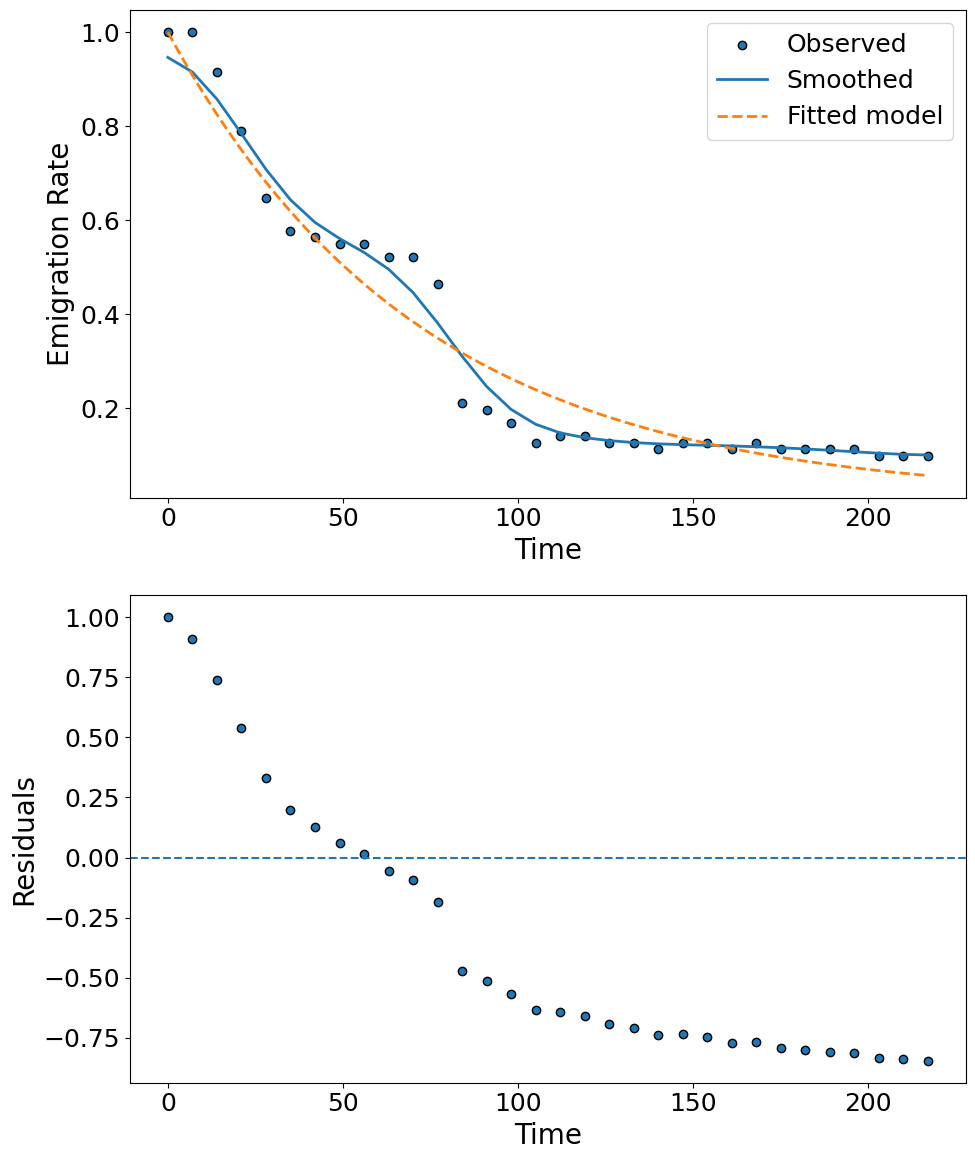

In [32]:
def load_and_preprocess(
    file_path: pathlib.Path, interval: str = 'W'
) -> pd.DataFrame:
    df = pd.read_csv(file_path, parse_dates=['timestamp'])
    df['time_interval'] = df['timestamp'].dt.to_period(interval)
    return df


def compute_initial_hull(
    df: pd.DataFrame, start_interval: pd.Period
) -> Tuple[np.ndarray, np.ndarray, List[str]]:
    start_df = df[df['time_interval'] == start_interval]
    pts = start_df[['location-long', 'location-lat']].to_numpy()
    hull = ConvexHull(pts)
    hull_pts = pts[hull.vertices]
    path = Path(hull_pts)

    mask = start_df.apply(
        lambda row: path.contains_point((row['location-long'], row['location-lat'])),
        axis=1
    )
    initial_ids = start_df.loc[mask, 'individual-local-identifier'].unique().tolist()
    return pts, hull_pts, initial_ids


def emigration_over_time(
    df: pd.DataFrame,
    hull_pts: np.ndarray,
    initial_ids: List[str],
    start: pd.Period,
    end: pd.Period
) -> Tuple[np.ndarray, np.ndarray]:
    path = Path(hull_pts)
    dates = []
    rates = []
    total_initial = len(initial_ids)

    for period, group in df.groupby('time_interval'):
        if period < start or period > end:
            continue

        inside_ids = group[
            group.apply(
                lambda r: path.contains_point((r['location-long'], r['location-lat'])),
                axis=1
            )
        ]['individual-local-identifier'].unique()

        absent = len(set(initial_ids) - set(inside_ids))
        rate = 1 - (absent / total_initial)
        dates.append(period.start_time.to_pydatetime())
        rates.append(rate)

    return np.array(dates), np.array(rates)


def fit_emigration_model(
    t: np.ndarray, y: np.ndarray
) -> Tuple[Tuple[float, float], float, np.ndarray]:
    def model(t_days, A, k):
        return (A + (np.exp(-k * t_days) * (1 - A)))

    best_r2, best_params, best_fit = -np.inf, None, None

    for A0 in np.linspace(0.1, 1.0, 10):
        for k0 in np.linspace(0.001, 0.1, 10):
            try:
                popt, _ = curve_fit(
                    model, t, y, p0=[A0, k0], bounds=([0, 0], [1, np.inf])
                )
                pred = model(t, *popt)
                ss_res = np.sum((y - pred) ** 2)
                ss_tot = np.sum((y - y.mean()) ** 2)
                r2 = 1 - (ss_res / ss_tot)

                if r2 > best_r2:
                    best_r2, best_params, best_fit = r2, tuple(popt), pred
            except RuntimeError:
                continue

    return best_params, best_r2, best_fit


def plot_results(
    days: np.ndarray,
    rates: np.ndarray,
    smoothed: np.ndarray,
    t_fit: np.ndarray,
    em_fit: np.ndarray,
    residuals: np.ndarray
) -> None:
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

    ax1.scatter(days, rates, label='Observed', edgecolor='k')
    ax1.plot(days, smoothed, label='Smoothed', lw=2)
    ax1.plot(t_fit, em_fit, '--', label='Fitted model', lw=2)
    ax1.set_xlabel("Time")
    ax1.set_ylabel("Emigration Rate")
    ax1.legend()

    ax2.scatter(days, residuals, edgecolor='k')
    ax2.axhline(0, ls='--')
    ax2.set_xlabel("Time")
    ax2.set_ylabel("Residuals")
    plt.tight_layout()
    plt.show()


def main():
    data_file = pathlib.Path(r"./data/Rhinoceros_Auklet_North_American_Pacific_Coast_(GLS)-tracks.csv")
    start_idx, end_idx = 49, 80

    df = load_and_preprocess(data_file, interval='W')
    intervals = df['time_interval'].unique()
    start_period, end_period = intervals[start_idx], intervals[end_idx]

    _, hull_pts, initial_ids = compute_initial_hull(df, start_period)

    dates, rates = emigration_over_time(df, hull_pts, initial_ids, start_period, end_period)
    smoothed = gaussian_filter1d(rates, sigma=2)
    days = (dates - dates[0]).astype('timedelta64[D]').astype(int)

    (A_opt, k_opt), r2, fitted = fit_emigration_model(days, rates)
    print(f"Optimized A={A_opt:.4f}, k={k_opt:.4f}, R²={r2:.4f}")

    t_fit = np.linspace(days.min(), days.max(), 200)
    em_fit = (A_opt + np.exp(-k_opt * t_fit) * (1 - A_opt))
    residuals = rates - (1 - (A_opt + np.exp(-k_opt * days) * (1 - A_opt)))
    plot_results(days, rates, smoothed, t_fit, em_fit, residuals)

if __name__ == "__main__":
    main()


### Figure 6

Calculating probabilities...
Total probability before normalization: 6.198771
Total probability after normalization: 1.000000

Statistics:
Maximum probability: 7.51e-03
Occurs at N=80, r=5
Mean N (weighted): 205.3


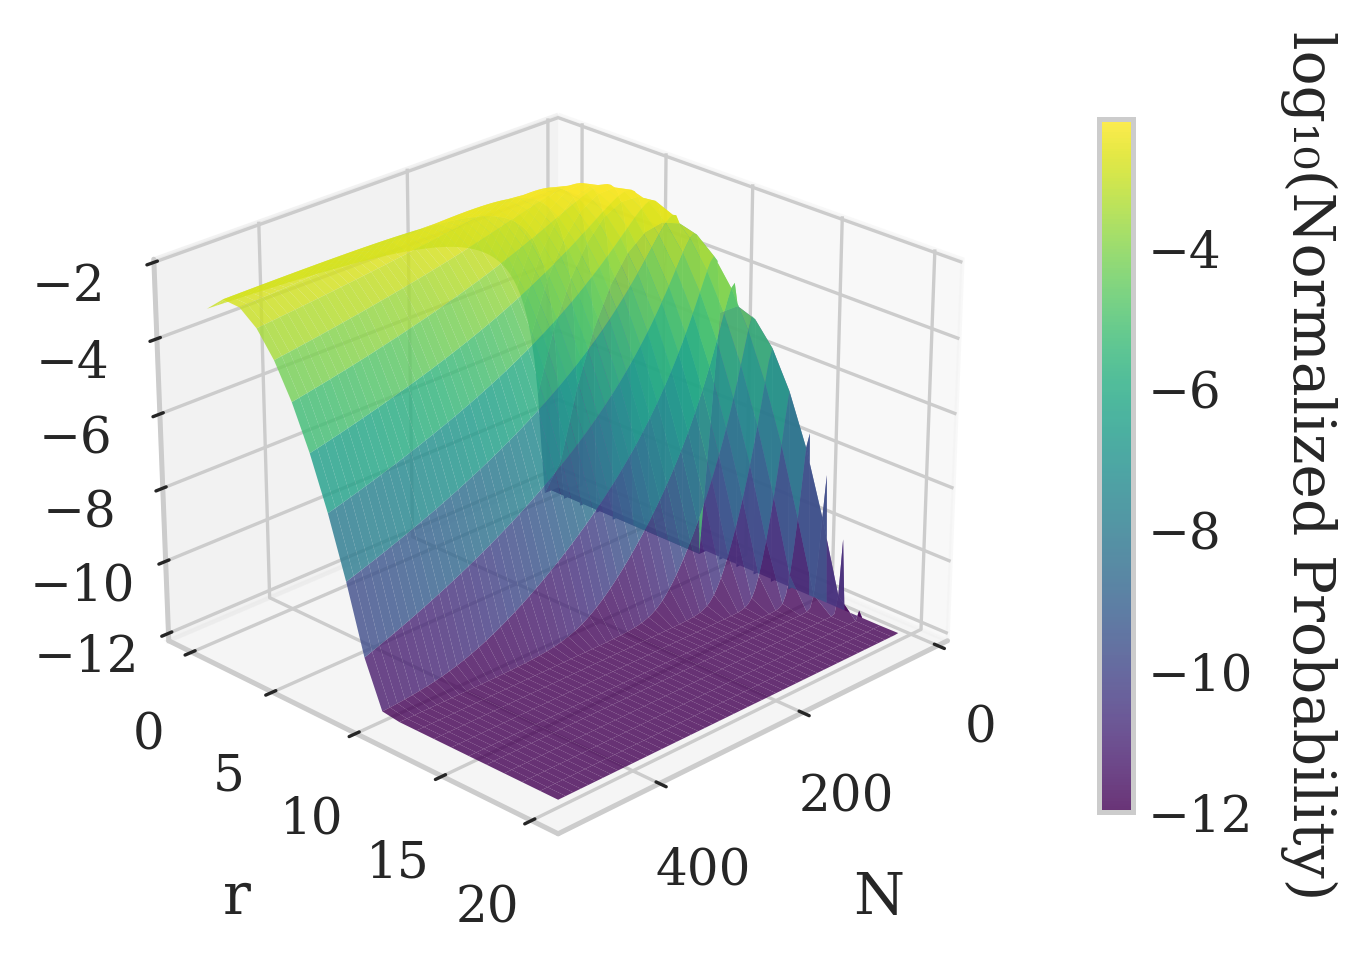

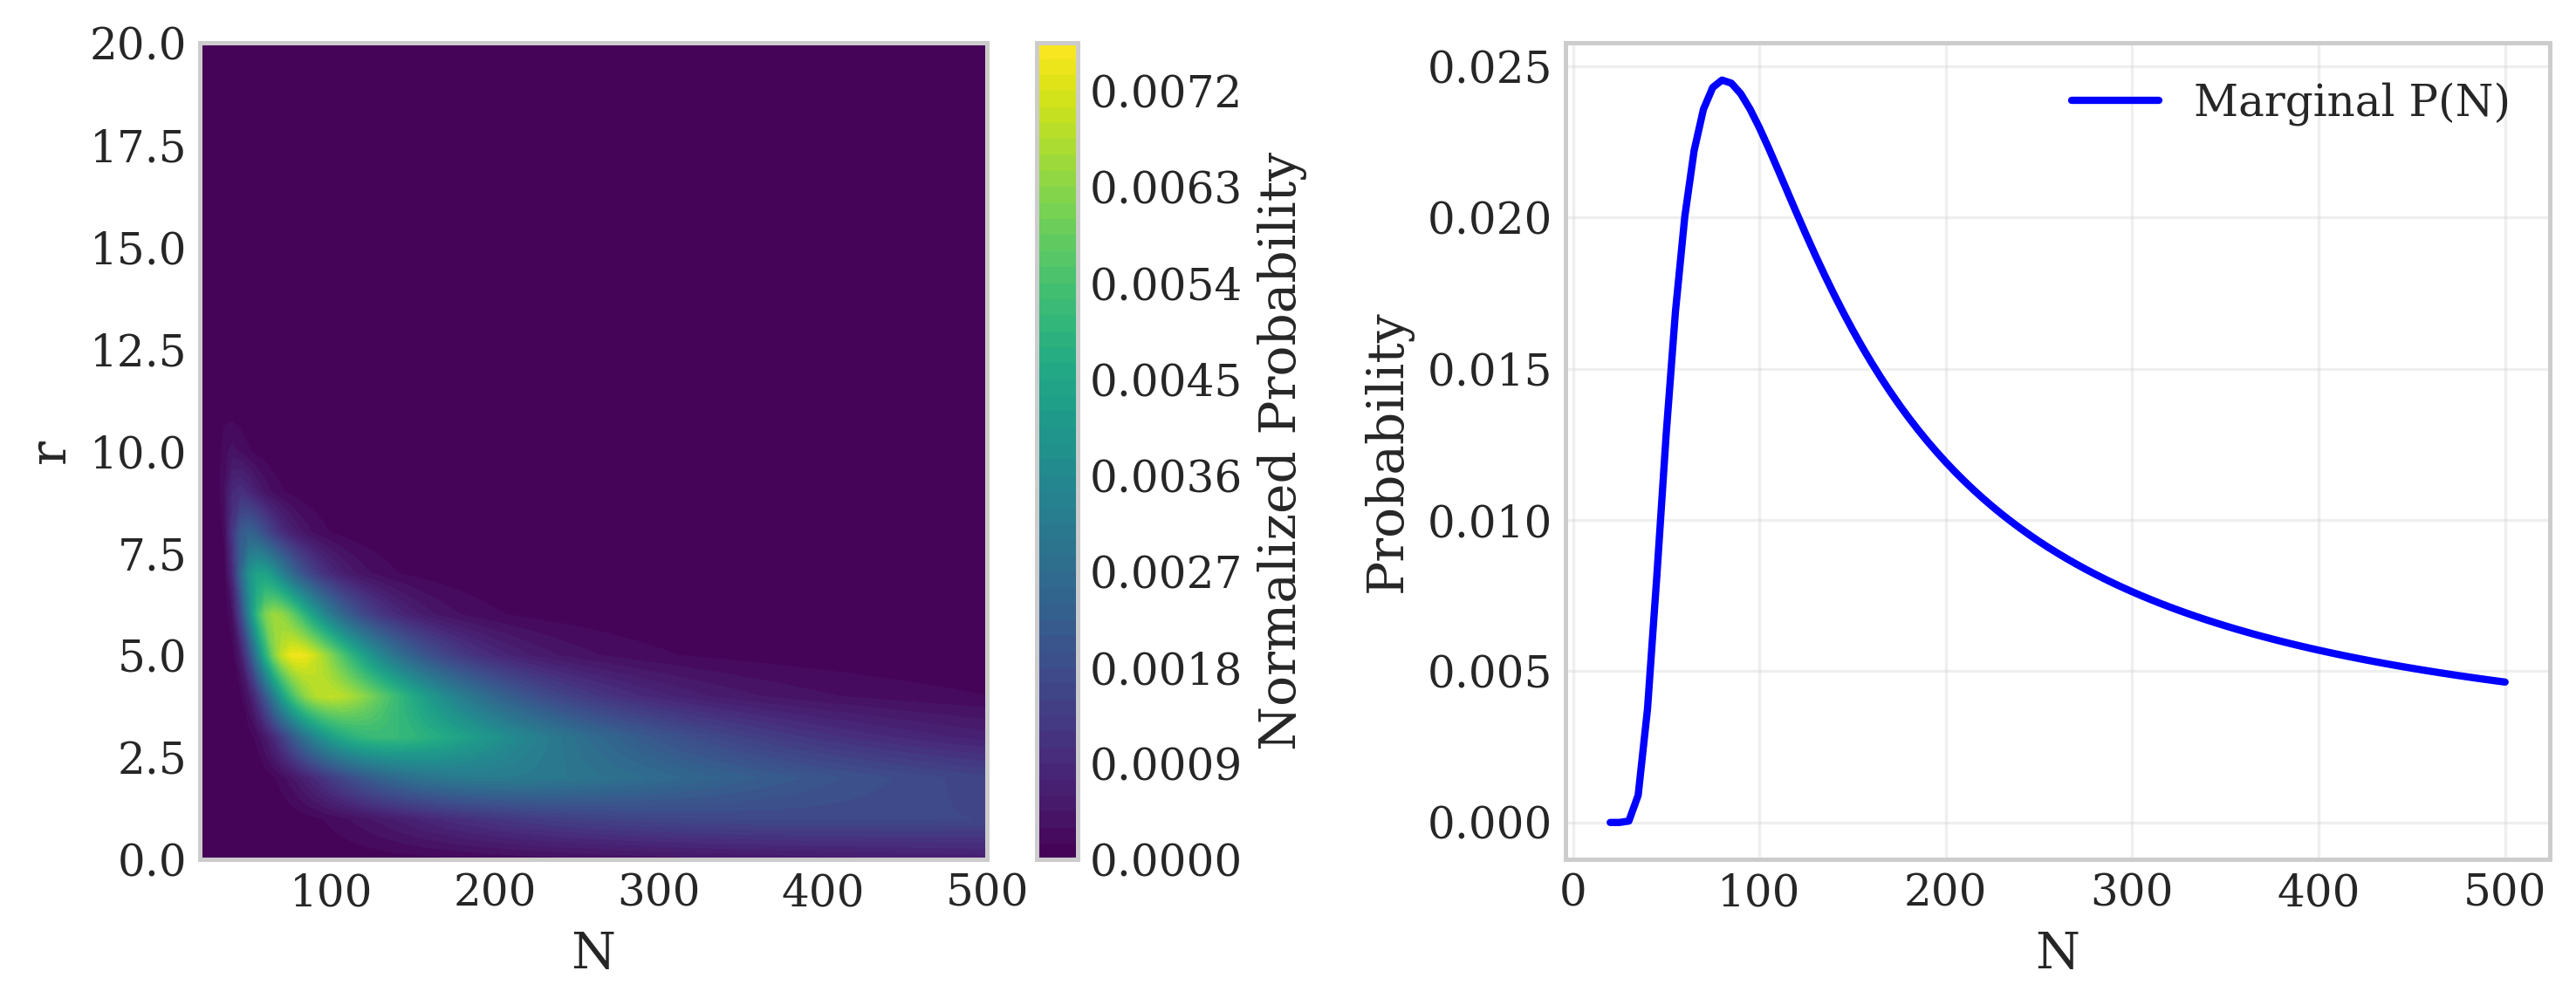

In [36]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'axes.linewidth': 1.2,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

def calculate_probability(N, r, C=20, m=20, mu=5, sigma=2):
    if N < C or m < r or (N - m) < (C - r) or r < 0 or N <= 0:
        return 0.0
    
    try:
        hypergeom = (comb(m, r, exact=False) * comb(N - m, C - r, exact=False)) / comb(N, C, exact=False)
        normal_comp = norm.pdf(r, loc=mu, scale=sigma)
        prob = hypergeom * normal_comp
        return prob if not np.isnan(prob) and not np.isinf(prob) else 0.0
    except (ValueError, OverflowError):
        return 0.0

N_max = 500
C, m = 20, 20
mu, sigma = 5, 2

N_range = np.arange(C, N_max + 1, 5)
r_range = np.arange(0, min(m + 1, 25), 1)

N_grid, r_grid = np.meshgrid(N_range, r_range)

prob_grid = np.zeros_like(N_grid, dtype=float)

print("Calculating probabilities...")
for i, N_val in enumerate(N_range):
    for j, r_val in enumerate(r_range):
        prob_grid[j, i] = calculate_probability(N_val, r_val, C, m, mu, sigma)

total_prob = np.sum(prob_grid)
if total_prob > 0:
    prob_grid_normalized = prob_grid / total_prob
else:
    prob_grid_normalized = prob_grid

print(f"Total probability before normalization: {total_prob:.6f}")
print(f"Total probability after normalization: {np.sum(prob_grid_normalized):.6f}")

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection='3d')

prob_log = np.log10(prob_grid_normalized + 1e-12)

surf = ax.plot_surface(N_grid, r_grid, prob_log, 
                      cmap='viridis', 
                      alpha=0.8,
                      linewidth=0,
                      antialiased=True,
                      edgecolors='none')

cbar = plt.colorbar(surf, ax=ax, shrink=0.6, aspect=20, pad=0.1)
cbar.set_label('log₁₀(Normalized Probability)', rotation=270, labelpad=20)

ax.set_xlabel('N', labelpad=10)
ax.set_ylabel('r', labelpad=10)
ax.set_zlabel('log₁₀(Probability)', labelpad=10)

ax.view_init(elev=25, azim=45)
ax.grid(True, alpha=0.3)

fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

contour = ax1.contourf(N_grid, r_grid, prob_grid_normalized, 
                      levels=50, cmap='viridis')
ax1.set_xlabel('N')
ax1.set_ylabel('r')
plt.colorbar(contour, ax=ax1, label='Normalized Probability')

marginal_N = np.sum(prob_grid_normalized, axis=0)
ax2.plot(N_range, marginal_N, 'b-', linewidth=2, label='Marginal P(N)')
ax2.set_xlabel('N')
ax2.set_ylabel('Probability')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()

max_prob_idx = np.unravel_index(np.argmax(prob_grid_normalized), prob_grid_normalized.shape)
max_N = N_range[max_prob_idx[1]]
max_r = r_range[max_prob_idx[0]]
max_prob = prob_grid_normalized[max_prob_idx]

print(f"\nStatistics:")
print(f"Maximum probability: {max_prob:.2e}")
print(f"Occurs at N={max_N}, r={max_r}")
print(f"Mean N (weighted): {np.average(N_range, weights=marginal_N):.1f}")

plt.show()

## Supplementary Figures

### Figure S1

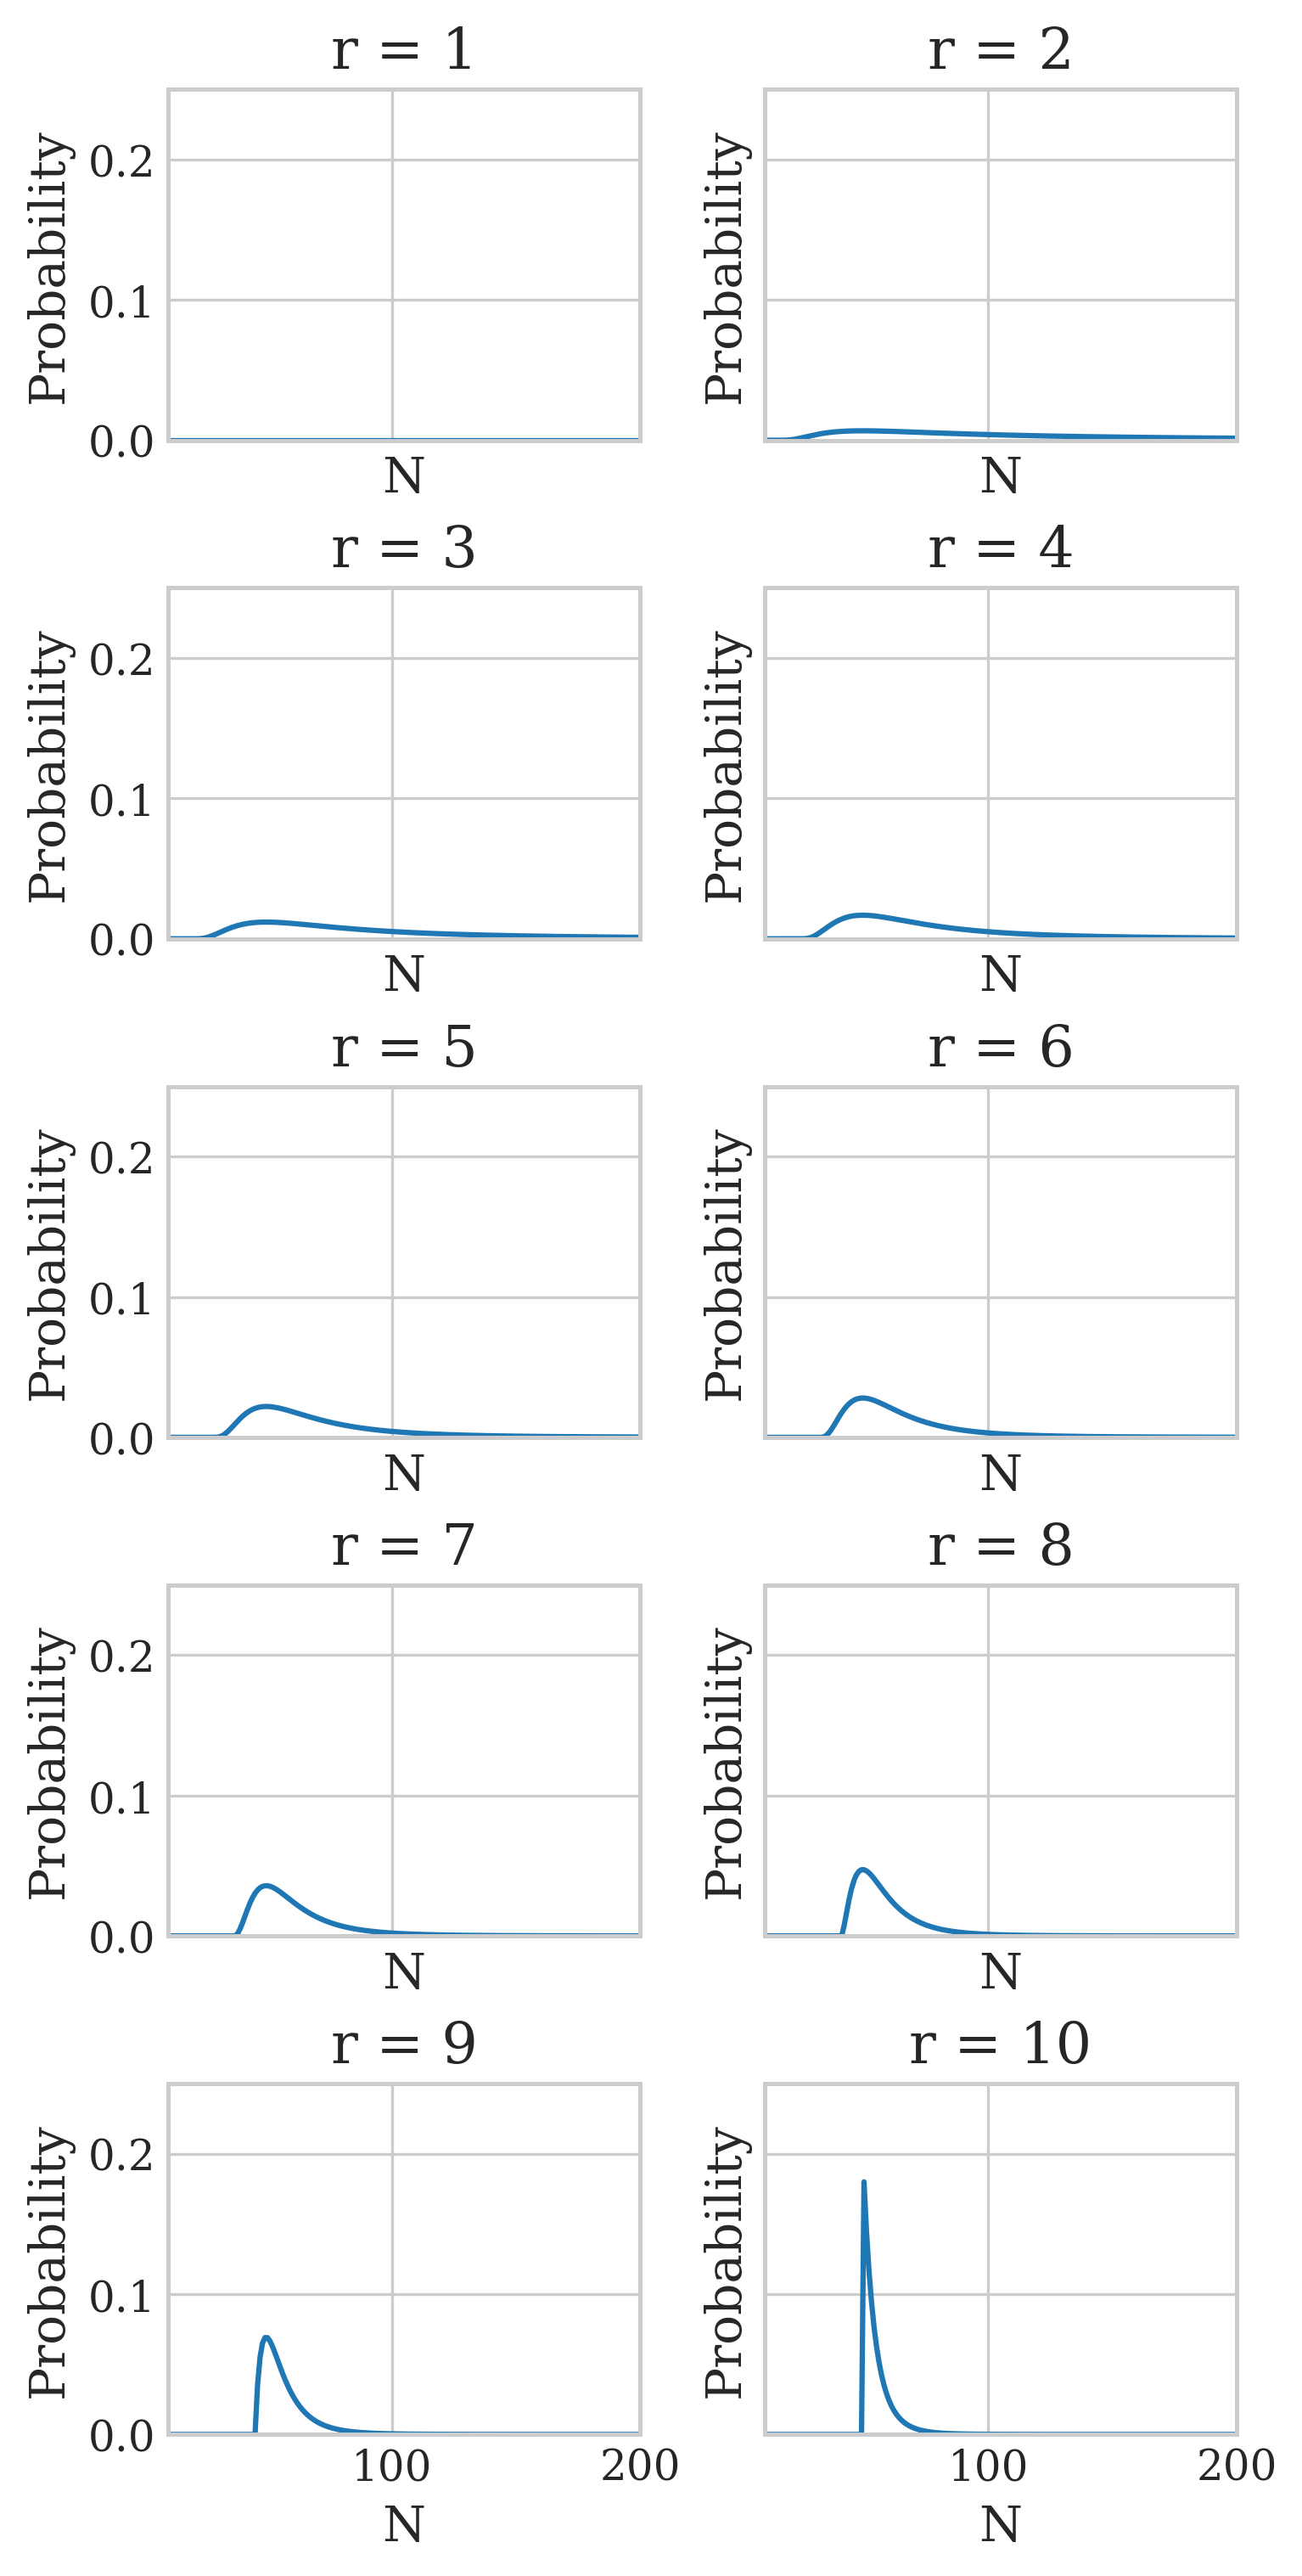

In [40]:
def nCr(n, r):
    return comb(n, r) if 0 <= r <= n else 0

C = 10
x = np.arange(C, 201)
y_min, y_max = 0, 0.25

fig, axes = plt.subplots(
    nrows=5,
    ncols=2,
    figsize=(5, 10),
    sharex=True,
    sharey=True,
    constrained_layout=True
)
axes = axes.flatten()

for ax, r in zip(axes, range(1, 11)):
    if r == 1:
        P_N = np.zeros_like(x, dtype=float)
    else:
        m = 5 * r
        factor = m * C / (r * (r - 1))
        numer = comb(m, r) * np.array([nCr(xi - m, C - r) for xi in x])
        denom = np.array([comb(xi, C) for xi in x]) * factor
        with np.errstate(divide='ignore', invalid='ignore'):
            P_N = np.where(denom != 0, numer / denom, 0.0)

    ax.plot(x, P_N)
    ax.set_title(f"r = {r}")
    ax.set_xlim(C, x[-1])
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel("N")
    ax.set_ylabel("Probability")

plt.show();

### Figure S2

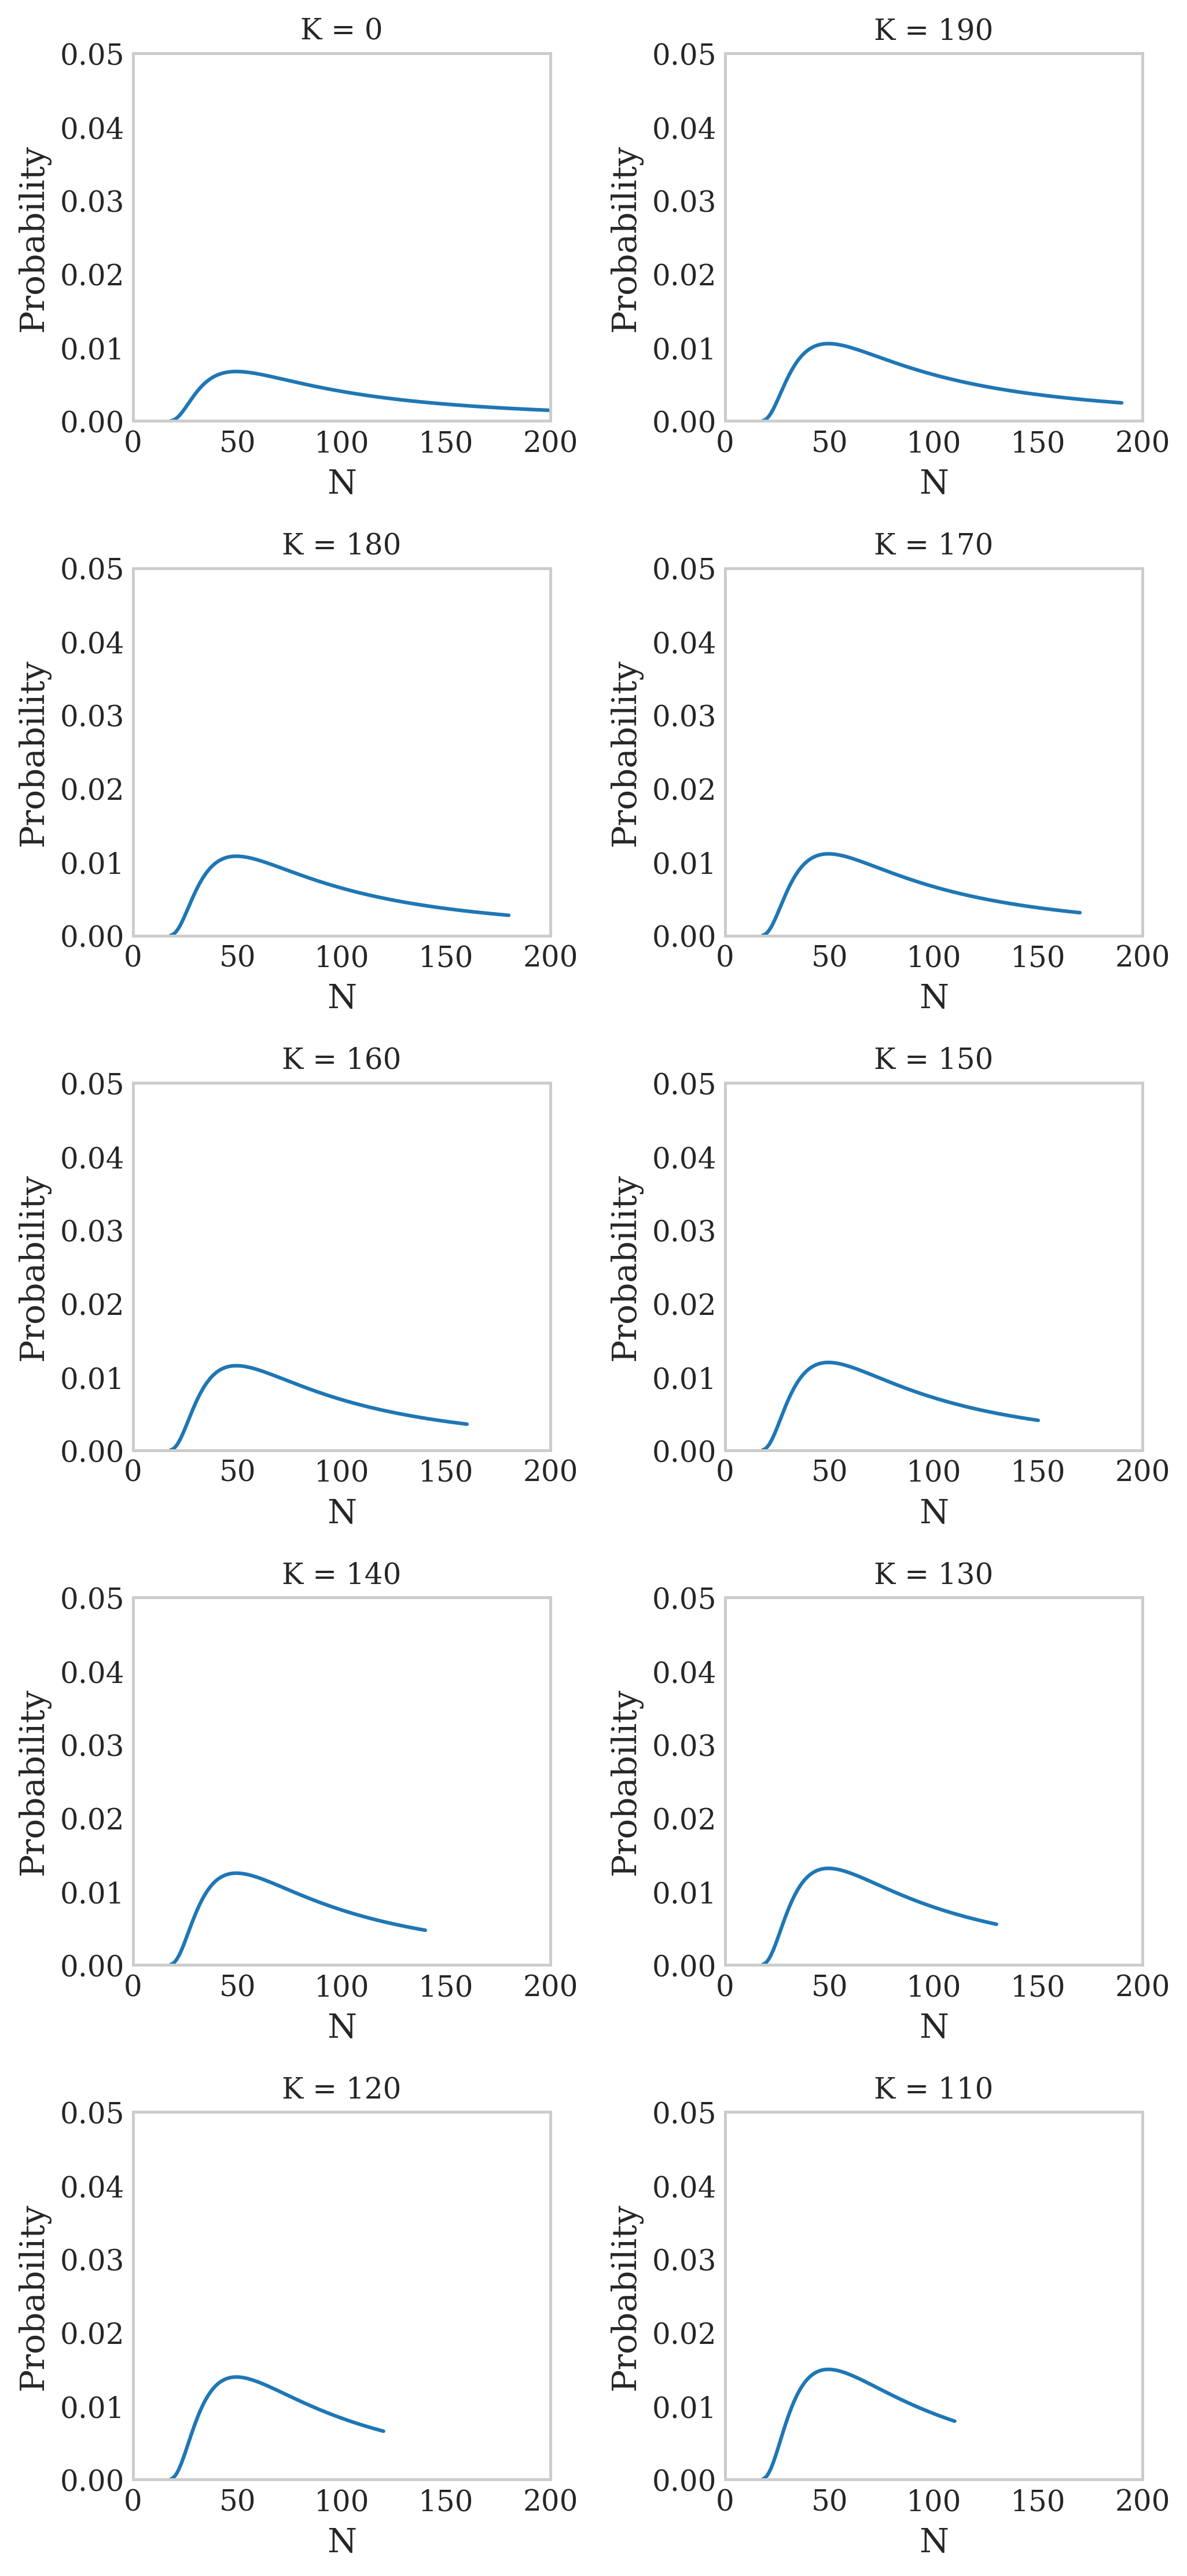

In [42]:
def P(x, m=10, C=10, r=2):
    if not (isinstance(x, (int, np.integer)) or float(x).is_integer()):
        return 0.0
    x = int(x)
    if x < m + C - r:
        return 0.0
    return comb(m, r) * comb(x - m, C - r) / comb(x, C)

def plot_normalized_distribution(ax, x_min, x_max, normalize_by=None, title=""):
    x = np.arange(x_min, x_max + 1)
    p_vals = np.array([P(xi) for xi in x])
    
    if normalize_by == "constant":
        factor = m * C / (r * (r - 1))
        y = p_vals / factor
    elif normalize_by == "cumulative":
        total = p_vals.sum()
        y = p_vals / total
    else:
        y = p_vals
    
    ax.plot(x, y, linewidth=1.5)
    ax.set_xlim(0, 200)
    ax.set_ylim(0, 0.05)
    ax.set_ylabel("Probability")
    ax.set_xlabel("N")
    ax.set_title(title, fontsize=12)
    ax.grid(False)

if __name__ == "__main__":
    m, C, r = 10, 10, 2
    x_min = m + C - r
    K_values = [None] + list(range(190, 100, -10))

    fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(7, 15))
    axes = axes.flatten()

    for ax, K in zip(axes, K_values):
        if K is None:
            plot_normalized_distribution(
                ax,
                x_min,
                200,
                normalize_by="constant",
                title="K = 0"
            )
        else:
            plot_normalized_distribution(
                ax,
                x_min,
                K,
                normalize_by="cumulative",
                title=f"K = {K}"
            )
    for ax in axes[len(K_values):]:
        fig.delaxes(ax)

    plt.tight_layout()
    plt.show();
